In [2]:
import os, sys, glob, shutil, re, pickle
import subprocess
import seaborn as sns

import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import math
import pyemma

from IPython.display import Image, display
%matplotlib inline
nmer = 5
mpl.rcParams.update({'font.size': 16})

## Important function

In [3]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [4]:
# Define the directory path
directory = "traj_data/"

remove_and_clean = True

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'traj_data/' have been cleared.


## Extract Distance Restraints

In [5]:
restraints_table = {
    'weak': 5,
    'medium': 3.5,
    'strong': 2.5
}

dist_res_file = '../../../utils/nspe_7_1_restraints.csv'
df_dist_res = pd.read_csv(dist_res_file)

for i, row in df_dist_res.iterrows():
    df_dist_res.at[i, df_dist_res.columns[2]] = restraints_table[row[2]]  # Correct mapping

# Make a look up table for intensity 
df_dist_res
dist_res = df_dist_res.values.tolist()
dist_res[:5]

/var/folders/d8/y2dvs1ln1gjcwccrkvtffr240000gn/T/ipykernel_63598/3498405480.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_dist_res.at[i, df_dist_res.columns[2]] = restraints_table[row[2]]  # Correct mapping


[[160, 165, 5], [160, 166, 5], [161, 165, 5], [161, 166, 5], [137, 165, 5]]

In [ ]:
gmx_distance_indices = np.array(df_dist_res.iloc[:, :2].values.tolist())

distance_indices = gmx_distance_indices - 1 

# Ensure the omega_data directory exists
omega_path = 'traj_data/'

state_num = 16
HREX_dir = '../traj'
run_num = 7 # How many run

HREX_list = [f"HREX_200ns_{i}" for i in range(1, run_num + 1)]
for state in range(state_num):
    dists_list = []
    for HREX in HREX_list:
        HREX_path = f"{HREX_dir}/{HREX}"  

        xtcfile = f"{HREX_path}/state_{state}/HREMD.part0001.xtc"
        grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
        
        # Load the trajectory
        traj = md.load(xtcfile, top=grofile)
        
        # Compute distances 
        dists = md.compute_distances(traj, distance_indices) * 10.0 # convert nm to Å
        dists_list.append(dists)
        
    # Save distances
    concatenated_dists = np.vstack(dists_list)
    data_object = Data(concatenated_dists)
    save_path = f"{omega_path}dis_state{state}.pkl"
    data_object.save(save_path)
    print(f"Saved distances for state {state} to {save_path}")


Saved omegas for state 0 to traj_data/dis_state0.pkl
Saved omegas for state 1 to traj_data/dis_state1.pkl
Saved omegas for state 2 to traj_data/dis_state2.pkl
Saved omegas for state 3 to traj_data/dis_state3.pkl
Saved omegas for state 4 to traj_data/dis_state4.pkl
Saved omegas for state 5 to traj_data/dis_state5.pkl
Saved omegas for state 6 to traj_data/dis_state6.pkl
Saved omegas for state 7 to traj_data/dis_state7.pkl
Saved omegas for state 8 to traj_data/dis_state8.pkl
Saved omegas for state 9 to traj_data/dis_state9.pkl
Saved omegas for state 10 to traj_data/dis_state10.pkl
Saved omegas for state 11 to traj_data/dis_state11.pkl
Saved omegas for state 12 to traj_data/dis_state12.pkl
Saved omegas for state 13 to traj_data/dis_state13.pkl
Saved omegas for state 14 to traj_data/dis_state14.pkl
Saved omegas for state 15 to traj_data/dis_state15.pkl


In [29]:
nstates = 16

dist_all = []
for i in range(nstates):
    dist_path = f"traj_data/dis_state{i}.pkl"
    dist = Data.load(dist_path)
    dist = dist.array_list
    print(f'state {i}:, {np.array(dist).shape}')
    dist_all.append(dist)

dist_all = np.array(dist_all)
print(dist_all.shape)



state 0:, (140007, 76)
state 1:, (140007, 76)
state 2:, (140007, 76)
state 3:, (140007, 76)
state 4:, (140007, 76)
state 5:, (140007, 76)
state 6:, (140007, 76)
state 7:, (140007, 76)
state 8:, (140007, 76)
state 9:, (140007, 76)
state 10:, (140007, 76)
state 11:, (140007, 76)
state 12:, (140007, 76)
state 13:, (140007, 76)
state 14:, (140007, 76)
state 15:, (140007, 76)
(16, 140007, 76)


### Distribution of all restraints 

In [8]:
## Featurize the structure 
grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
feat = pyemma.coordinates.featurizer(grofile) 
feat.add_distances([67, 16])
feat.describe()

04-07-25 14:05:20 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[0] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


['DIST: H02 1 H5 16 - R02 3 H10 67']

In [9]:
dist_res[:5]

[[160, 165, 5], [160, 166, 5], [161, 165, 5], [161, 166, 5], [137, 165, 5]]

04-07-25 14:05:20 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:20 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:20 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[3] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:20 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[4] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the outpu

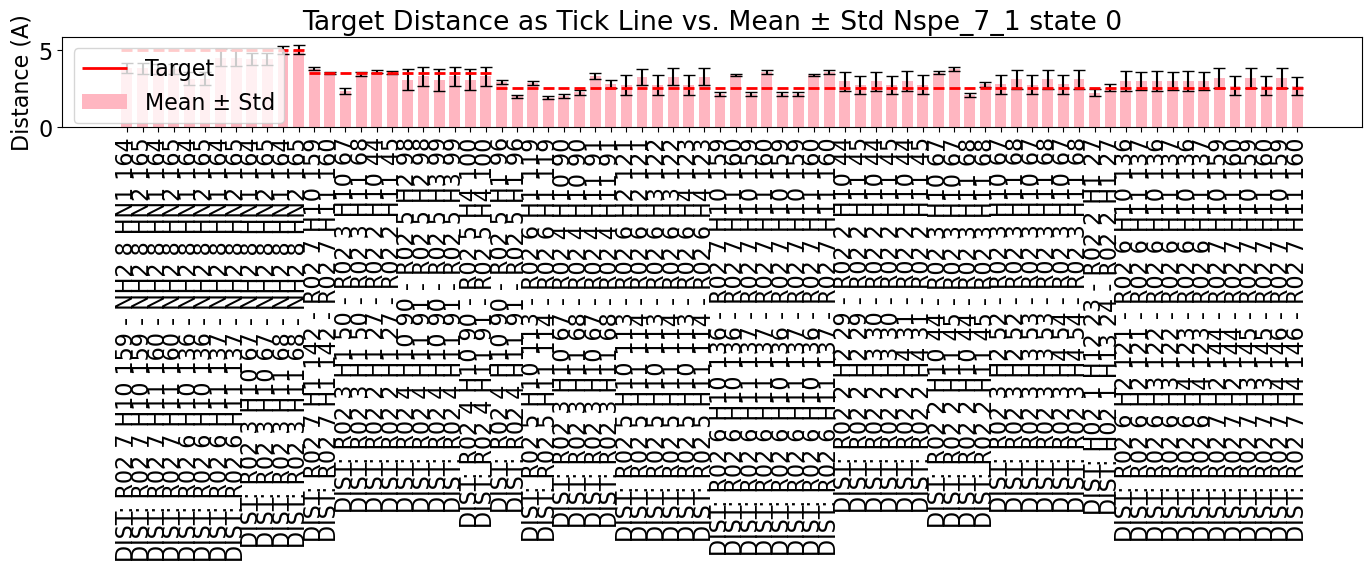

04-07-25 14:05:21 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[77] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:21 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[78] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:21 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[79] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:21 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[80] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the o

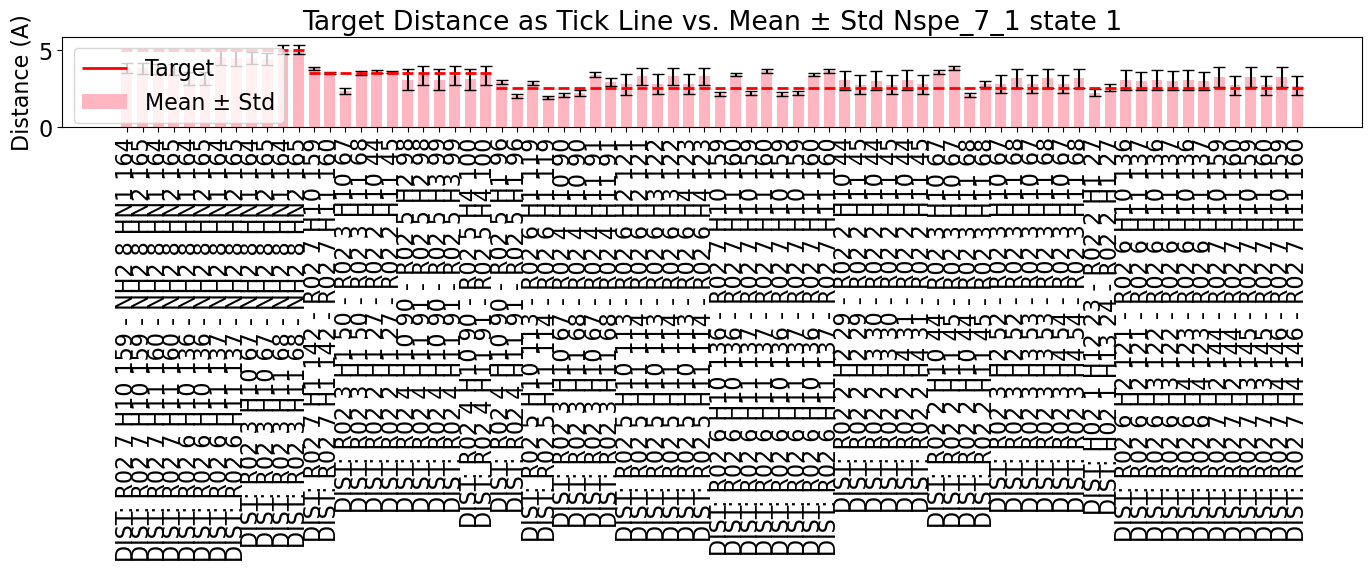

04-07-25 14:05:21 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[153] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:21 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[154] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:21 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[155] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:21 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[156] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

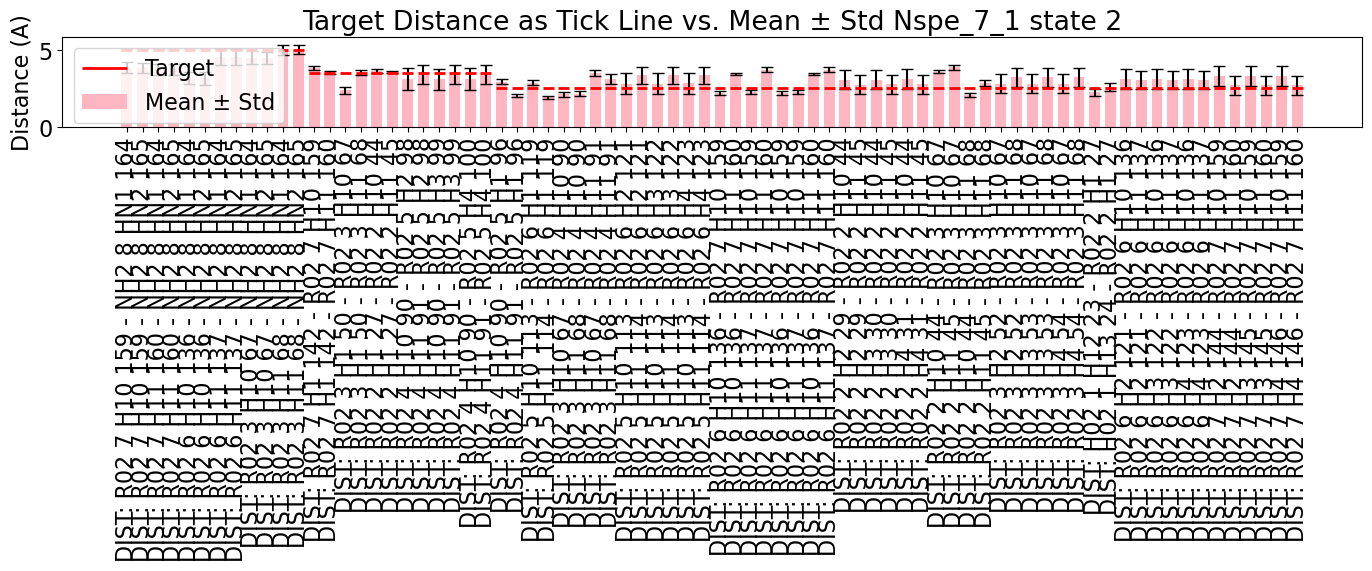

04-07-25 14:05:22 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[229] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:22 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[230] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:22 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[231] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:22 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[232] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

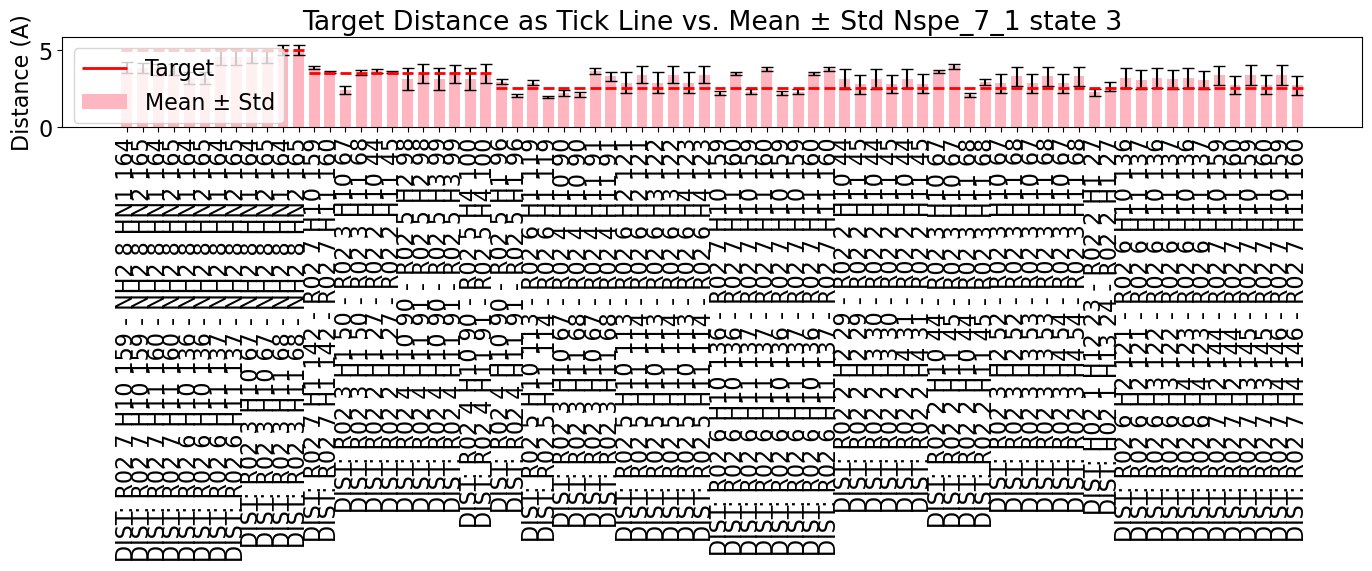

04-07-25 14:05:22 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[305] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:22 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[306] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:22 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[307] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:22 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[308] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

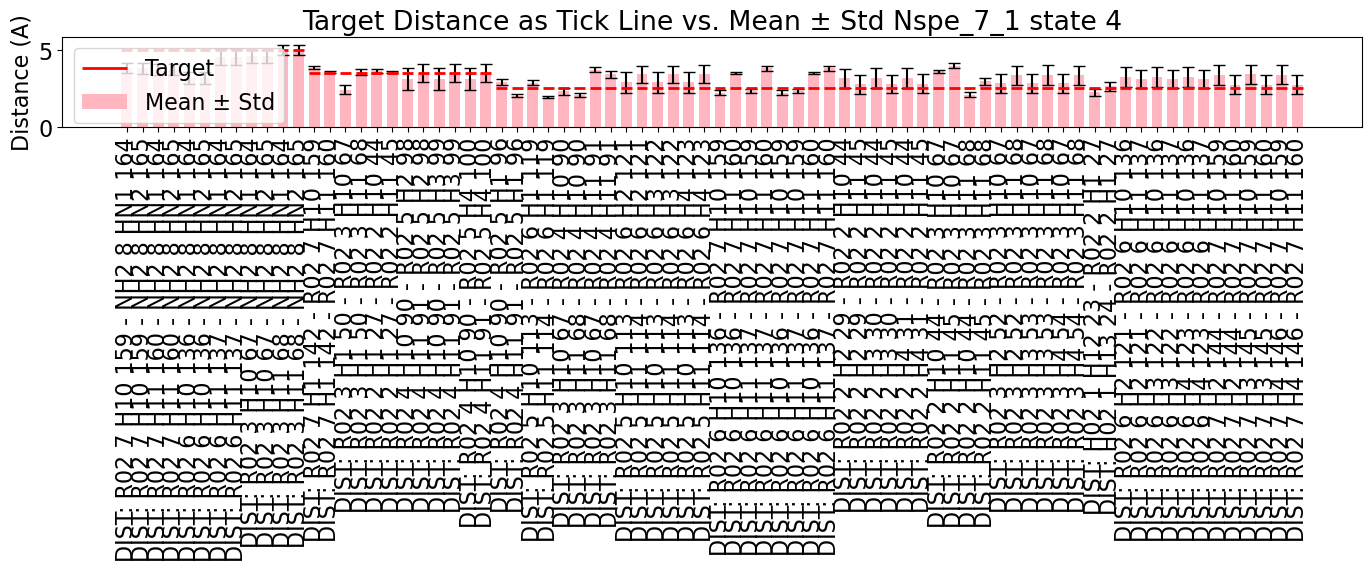

04-07-25 14:05:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[381] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[382] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[383] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[384] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

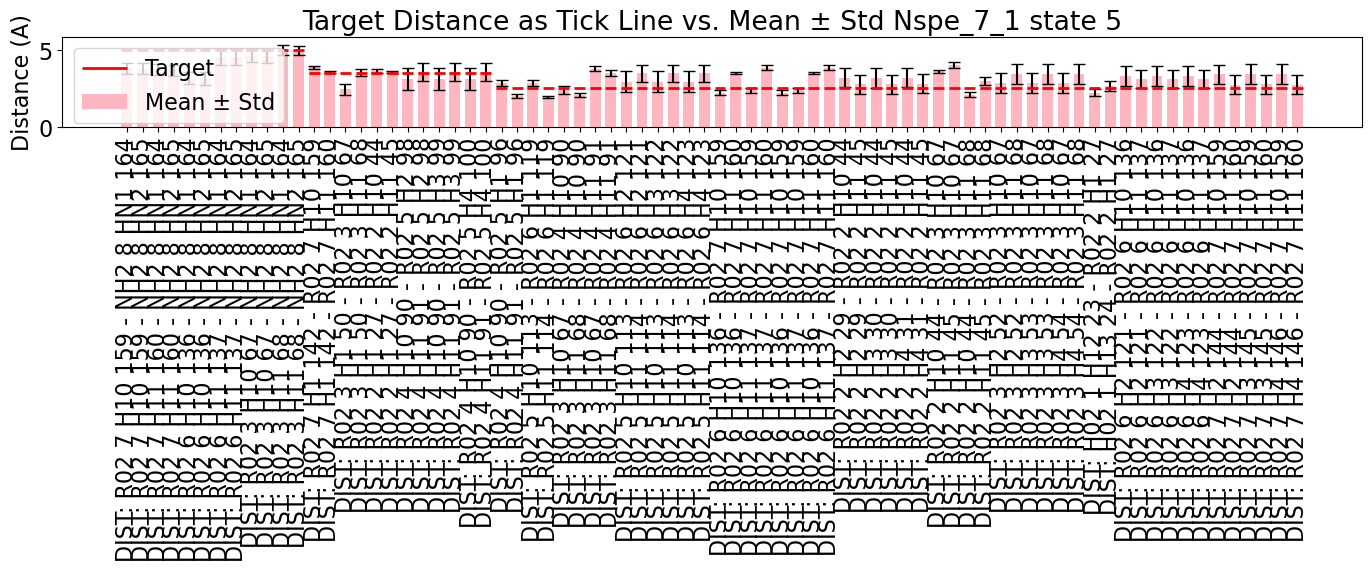

04-07-25 14:05:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[457] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[458] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[459] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[460] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

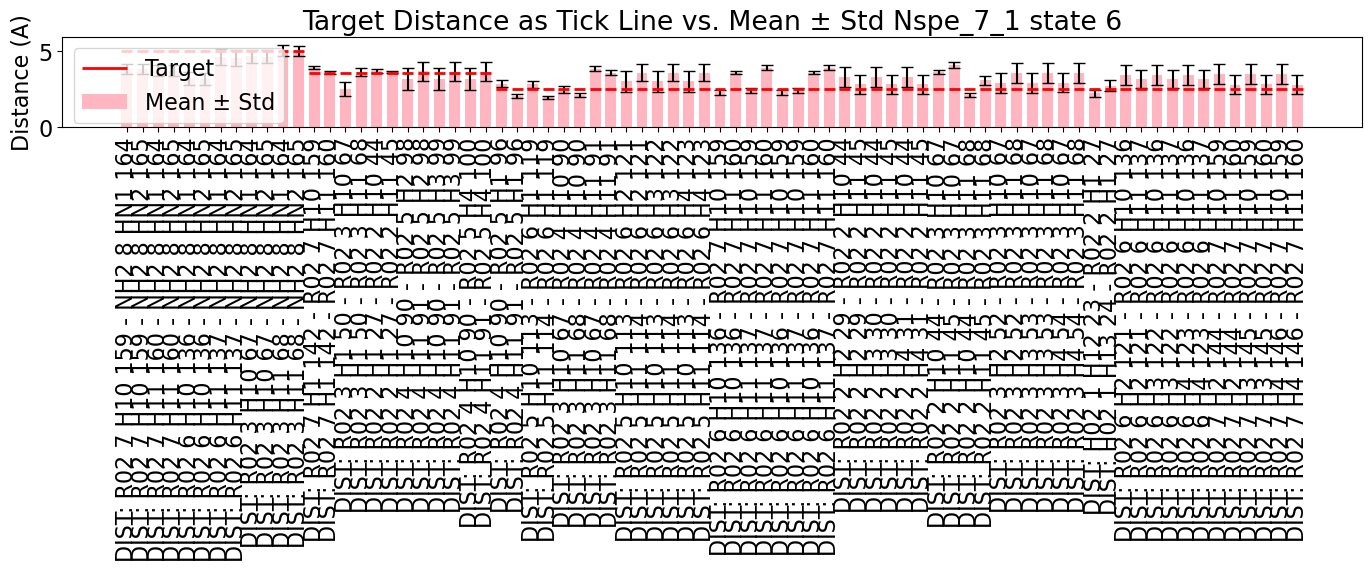

04-07-25 14:05:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[533] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[534] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[535] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[536] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

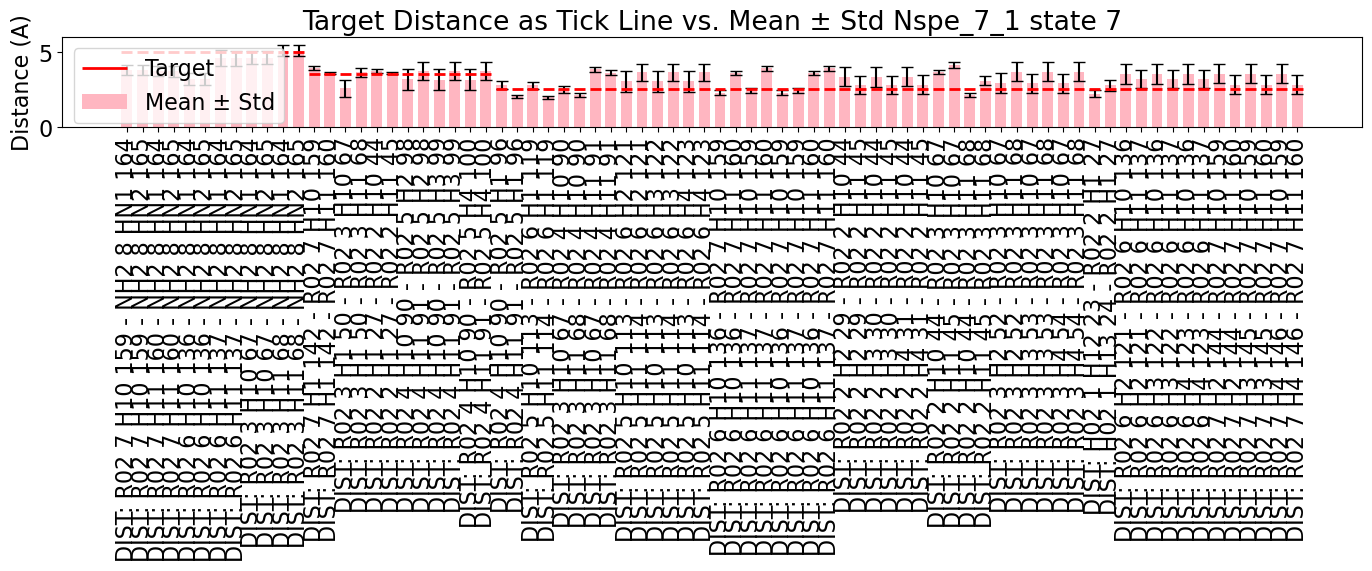

04-07-25 14:05:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[609] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[610] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[611] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[612] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

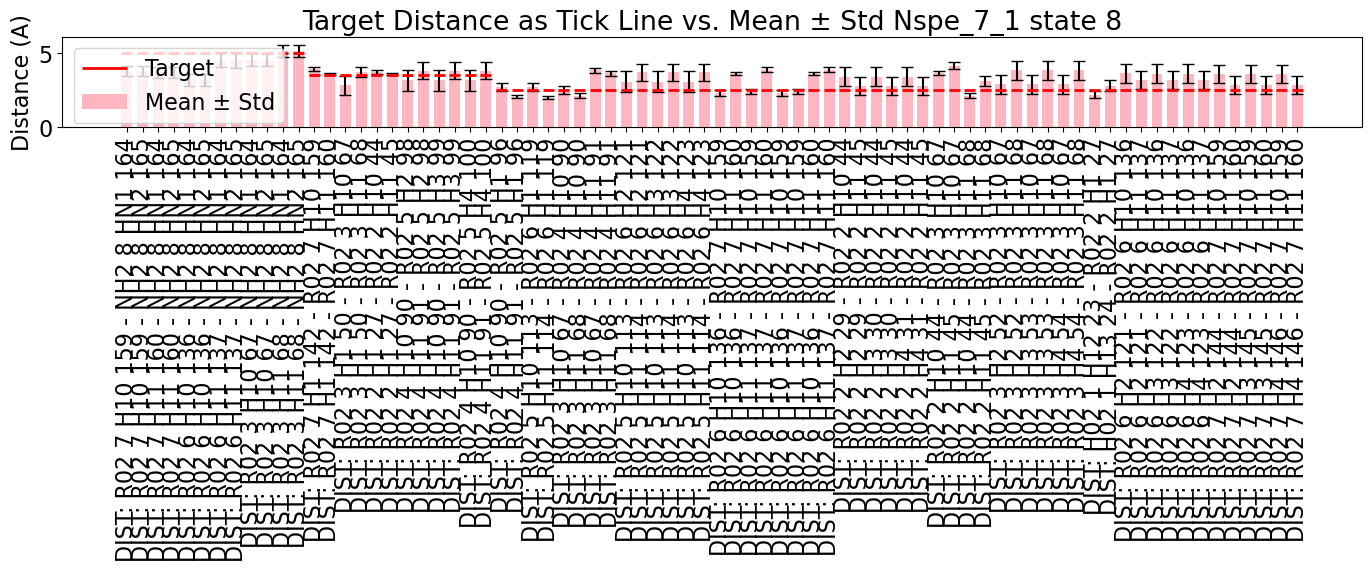

04-07-25 14:05:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[685] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[686] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[687] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[688] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

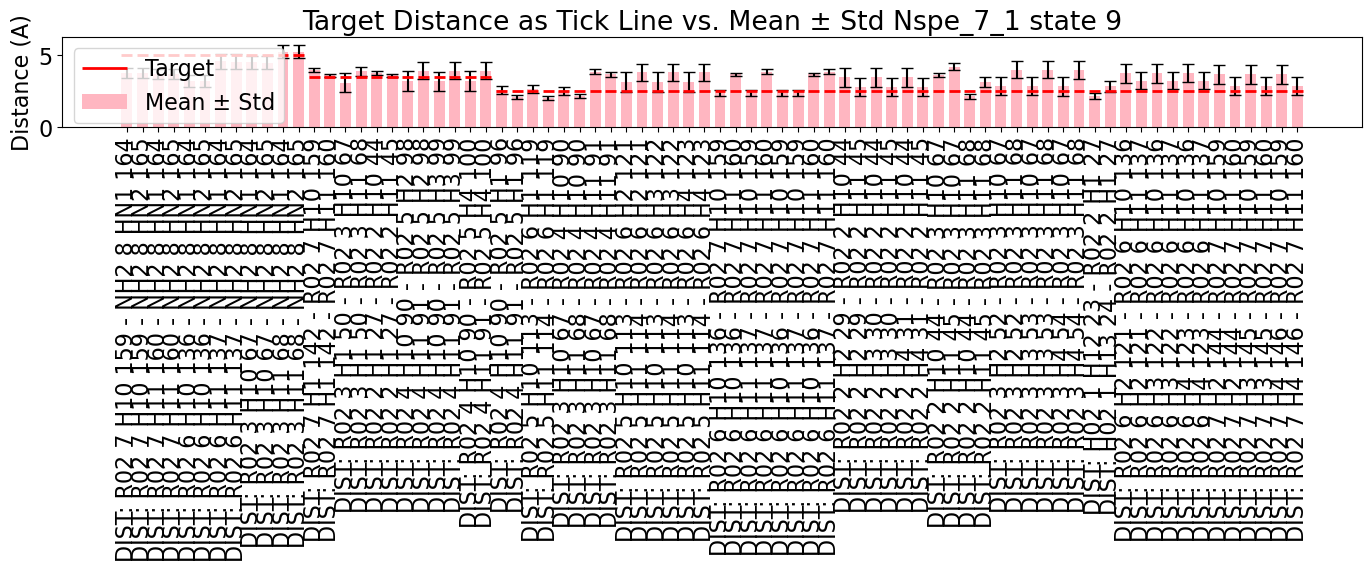

04-07-25 14:05:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[761] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[762] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[763] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[764] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

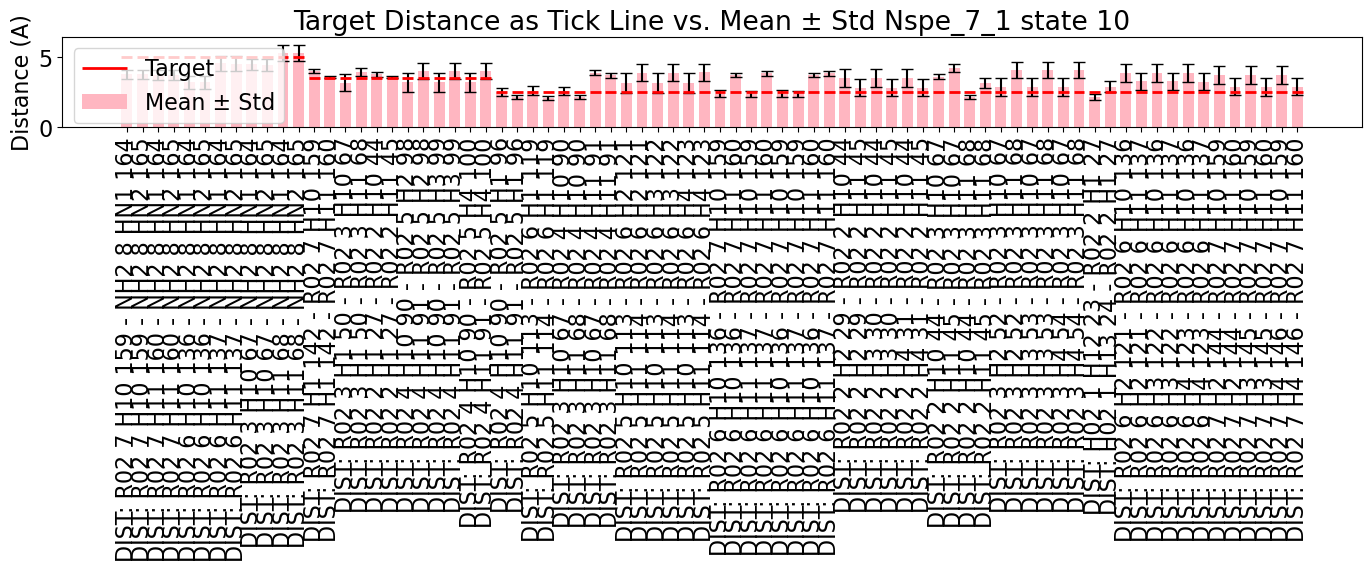

04-07-25 14:05:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[837] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[838] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[839] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[840] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

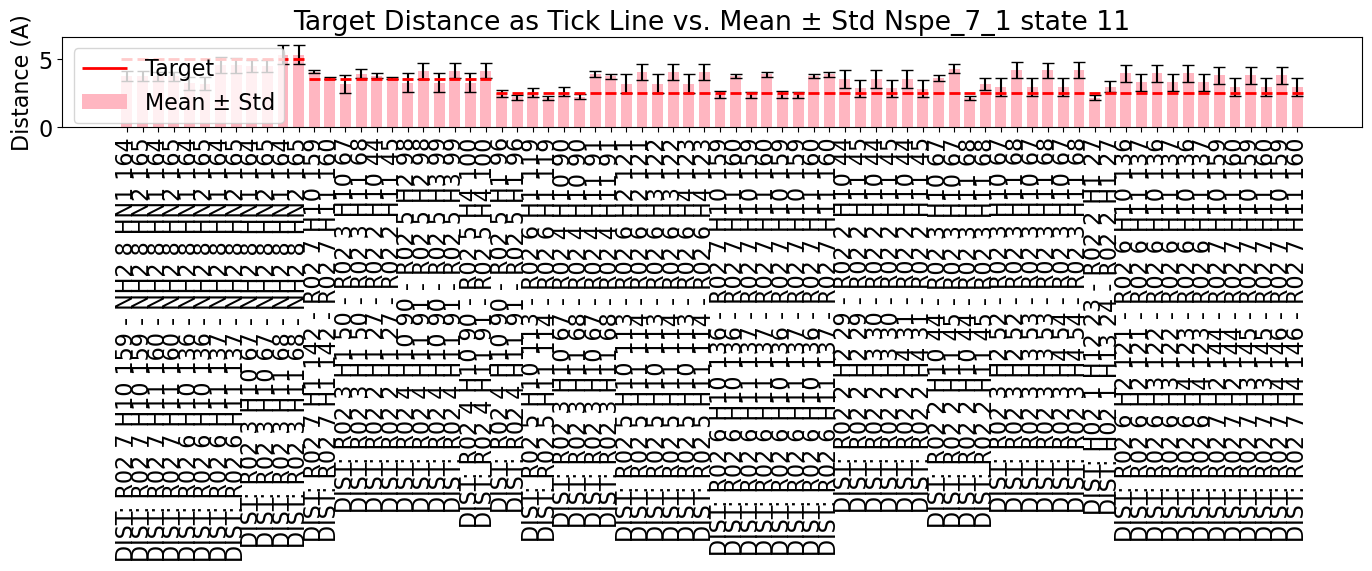

04-07-25 14:05:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[913] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[914] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[915] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[916] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

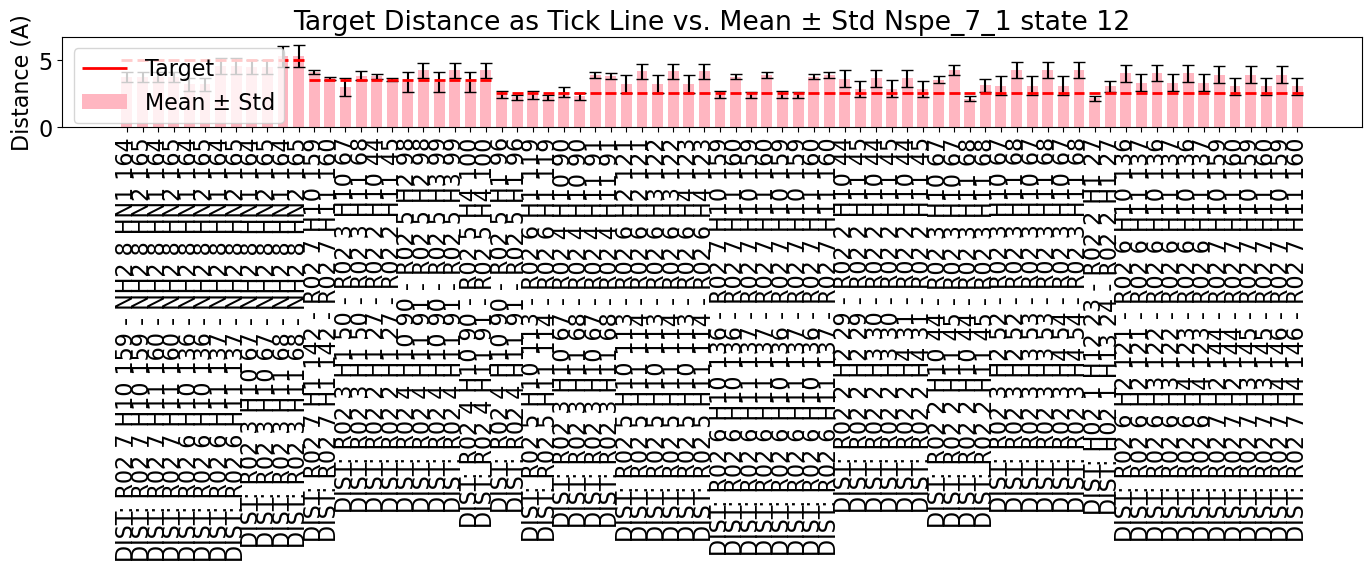

04-07-25 14:05:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[989] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[990] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[991] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[992] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check t

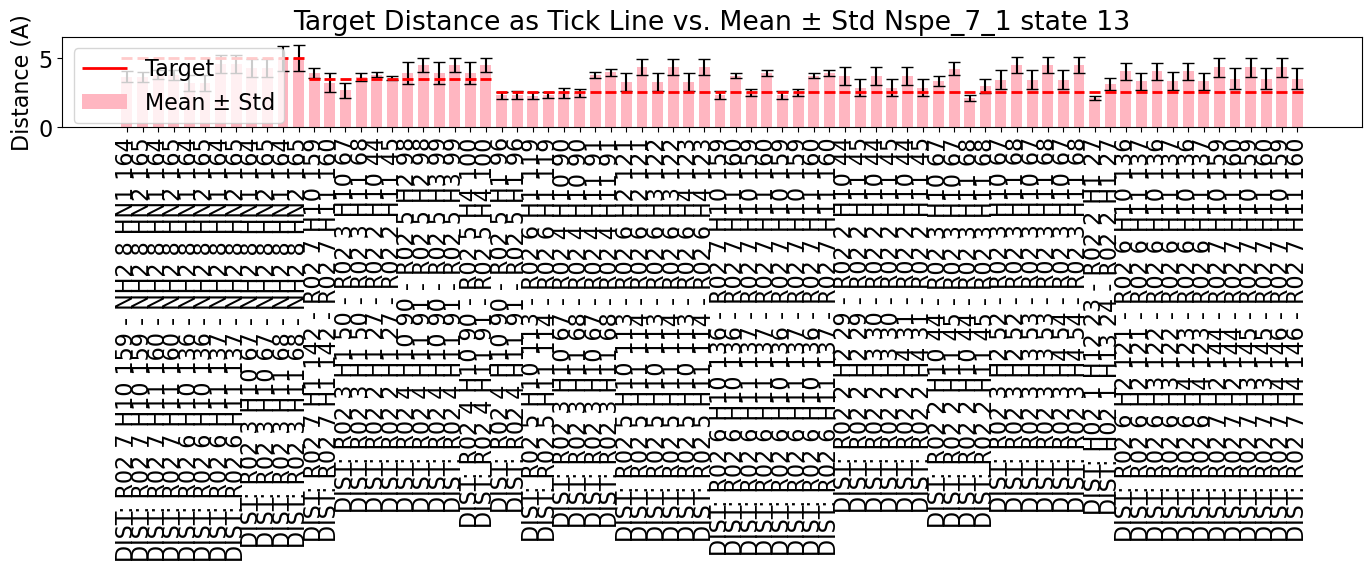

04-07-25 14:05:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1065] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1066] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1067] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1068] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Che

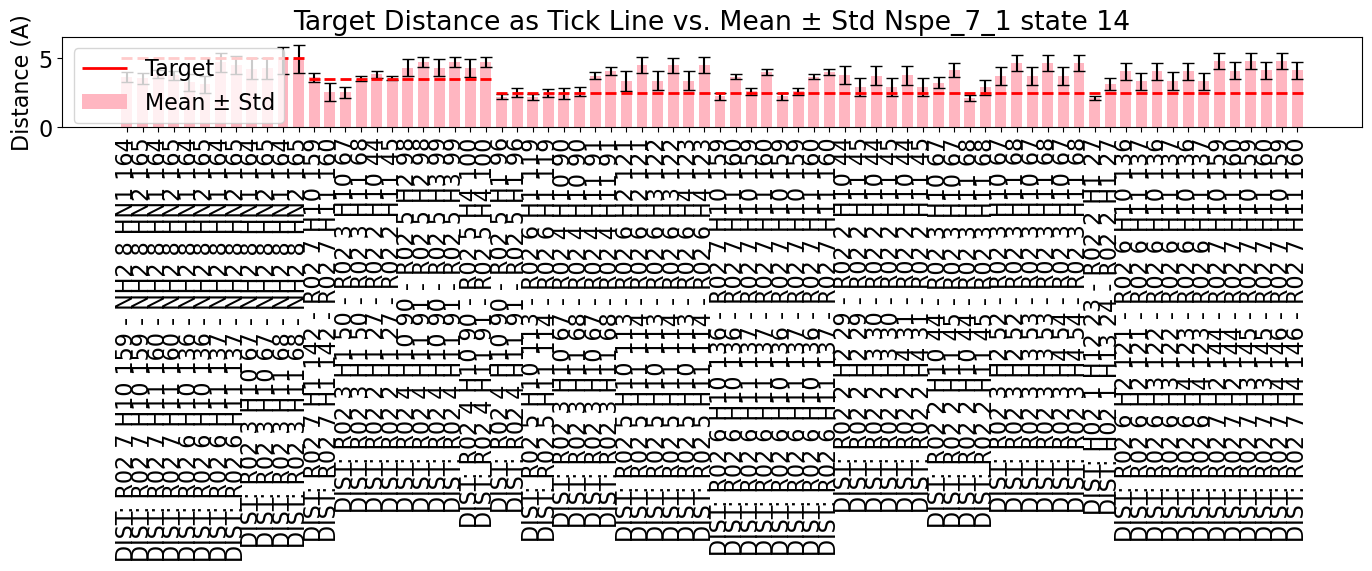

04-07-25 14:05:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1141] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1142] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1143] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
04-07-25 14:05:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1144] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Che

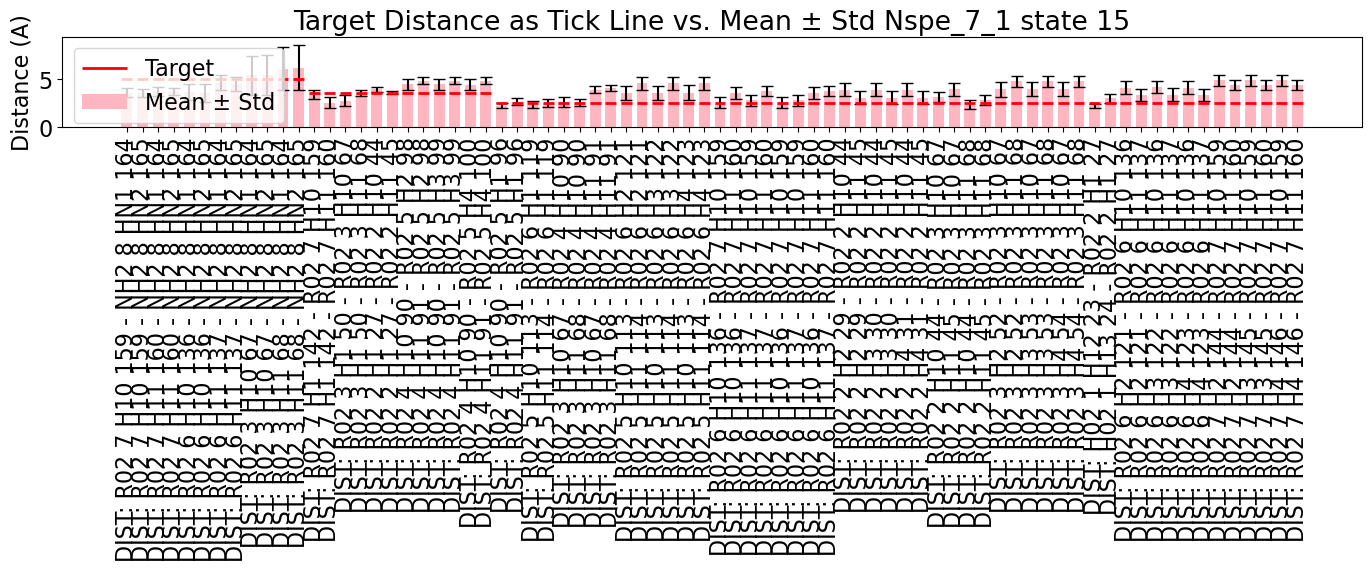

In [10]:
import matplotlib.pyplot as plt
import numpy as np

state_num = 16

for state in range(state_num):
    means = []
    stds = []
    targets = []
    labels = []

    for i in range(len(dist_res)):
        atom1, atom2, target = dist_res[i]
        atom1_pyemma = atom1 - 1
        atom2_pyemma = atom2 - 1
        dist = dist_all[state][:, i]

        mean_val = np.mean(dist)
        std_val = np.std(dist)

        means.append(mean_val)
        stds.append(std_val)
        targets.append(target)


        grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
        feat = pyemma.coordinates.featurizer(grofile) 
        feat.add_distances([atom1_pyemma, atom2_pyemma])
        label = feat.describe()[0]
        labels.append(label)
        #labels.append(f"{atom1}-{atom2}")

    # Convert to arrays
    means = np.array(means)
    stds = np.array(stds)
    targets = np.array(targets)

    x = np.arange(len(labels))
    width = 0.7

    plt.figure(figsize=(14, 6))

    # Plot mean ± std bars
    plt.bar(x, means, width, yerr=stds, capsize=4, label='Mean ± Std', color='lightpink')

    # Plot target as horizontal ticks (short lines)
    for xi, ti in zip(x, targets):
        plt.hlines(ti, xi - width/2, xi + width/2, colors='red', linestyles='-', linewidth=2, label='Target' if xi == 0 else None)

    plt.xticks(x, labels, rotation=90)
    plt.ylabel("Distance (A)")
    plt.title(f"Target Distance as Tick Line vs. Mean ± Std Nspe_7_1 state {state}")
    plt.ylim(0, max(np.max(means + stds), np.max(targets)) * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [11]:
atomtype_lookup = {
    ('H02', 'H12'): 'α11',
    ('H02', 'H13'): 'α11',
    ('H02', 'H3'): 'α2',
    ('H02', 'H4'): 'β3',
    ('H02', 'H5'): 'β3',
    ('H02', 'H6'): 'β3',
    ('R02', 'H10'): 'α11',
    ('R02', 'H11'): 'α11',
    ('R02', 'H1'): 'α2',
    ('R02', 'H2'): 'β3',
    ('R02', 'H3'): 'β3',
    ('R02', 'H4'): 'β3',
    ('NH2', 'HN1'): 'NH1',
    ('NH2', 'HN2'): 'NH1',
}


In [12]:
def translate_pyemma_label(label):
    # Remove 'DIST: ' prefix and whitespace
    label = label.replace('DIST: ', '').strip()
    
    # Split into two atoms
    part1, part2 = label.split(' - ')
    resname1, resid1, atomname1, atomid1 = part1.split()
    resname2, resid2, atomname2, atomid2 = part2.split()

    # Lookup group for each atom
    group1 = atomtype_lookup.get((resname1, atomname1), 'unknown')
    group2 = atomtype_lookup.get((resname2, atomname2), 'unknown')

    # Print (optional)
    print(f"Label: {label}")
    print(f"Residue 1: {resname1} {resid1}, Atom: {atomname1} ({atomid1}), Group: {group1}")
    print(f"Residue 2: {resname2} {resid2}, Atom: {atomname2} ({atomid2}), Group: {group2}")

    # Return formatted result
    return f"{resid1}{group1}-{resid2}{group2}"


In [13]:
label
translate_pyemma_label(label)

Label: R02 7 H4 146 - R02 7 H11 160
Residue 1: R02 7, Atom: H4 (146), Group: β3
Residue 2: R02 7, Atom: H11 (160), Group: α11


'7β3-7α11'

04-07-25 14:06:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1293] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1294] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:23 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1295] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

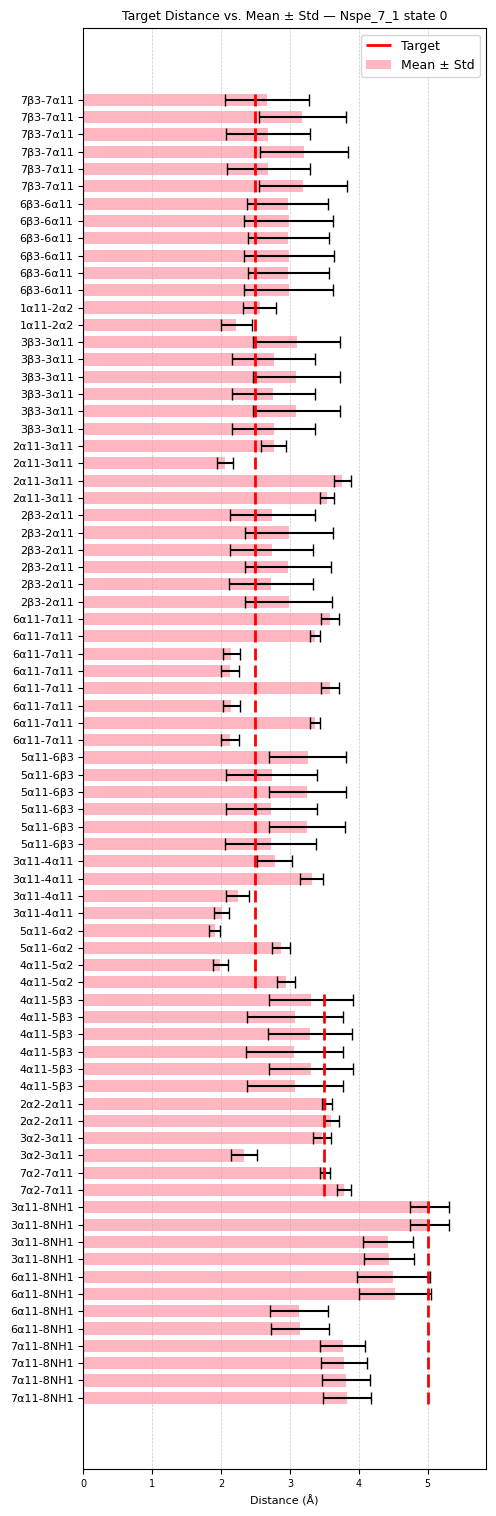

04-07-25 14:06:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1369] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1370] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1371] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

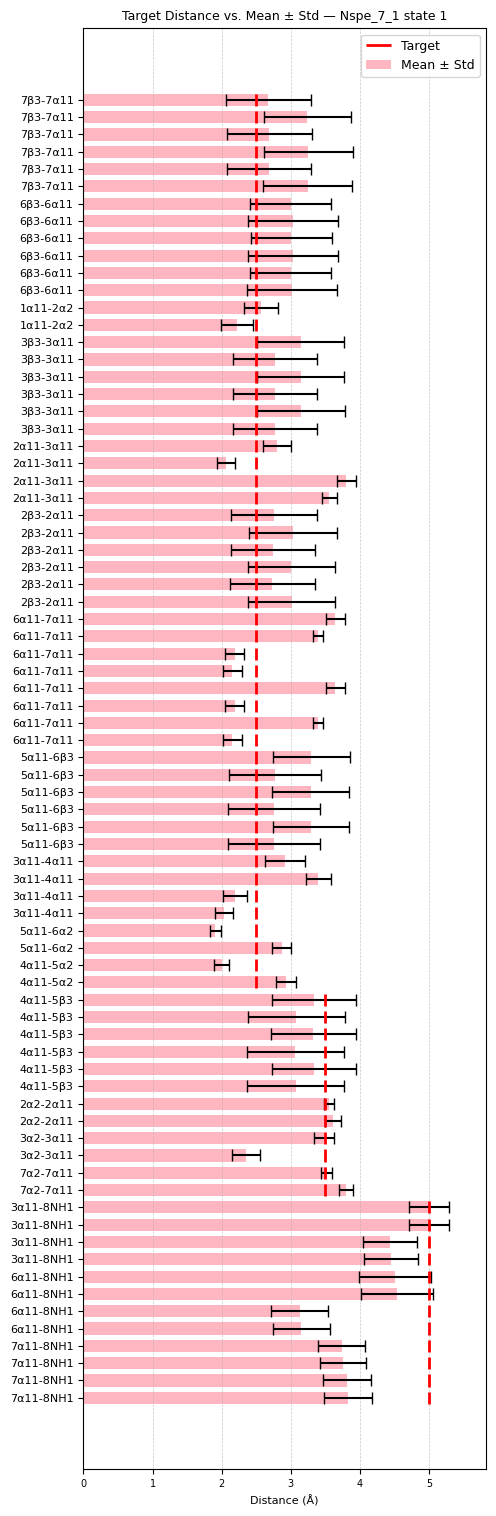

04-07-25 14:06:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1445] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1446] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:24 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1447] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

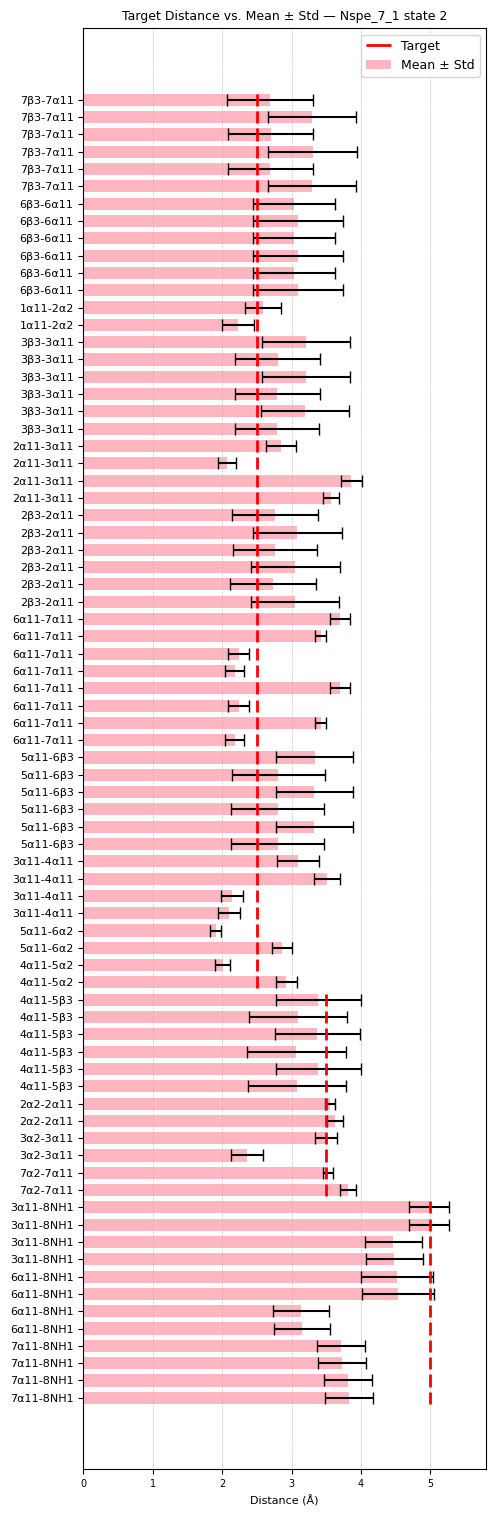

04-07-25 14:06:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1521] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1522] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1523] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

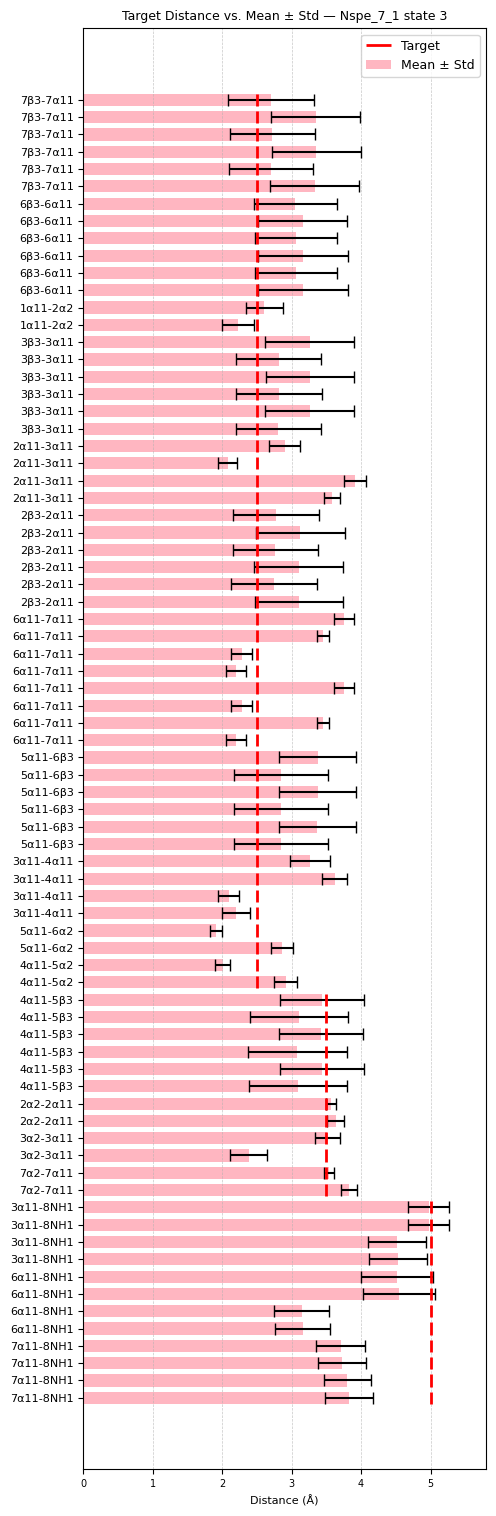

04-07-25 14:06:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1597] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1598] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:25 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1599] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

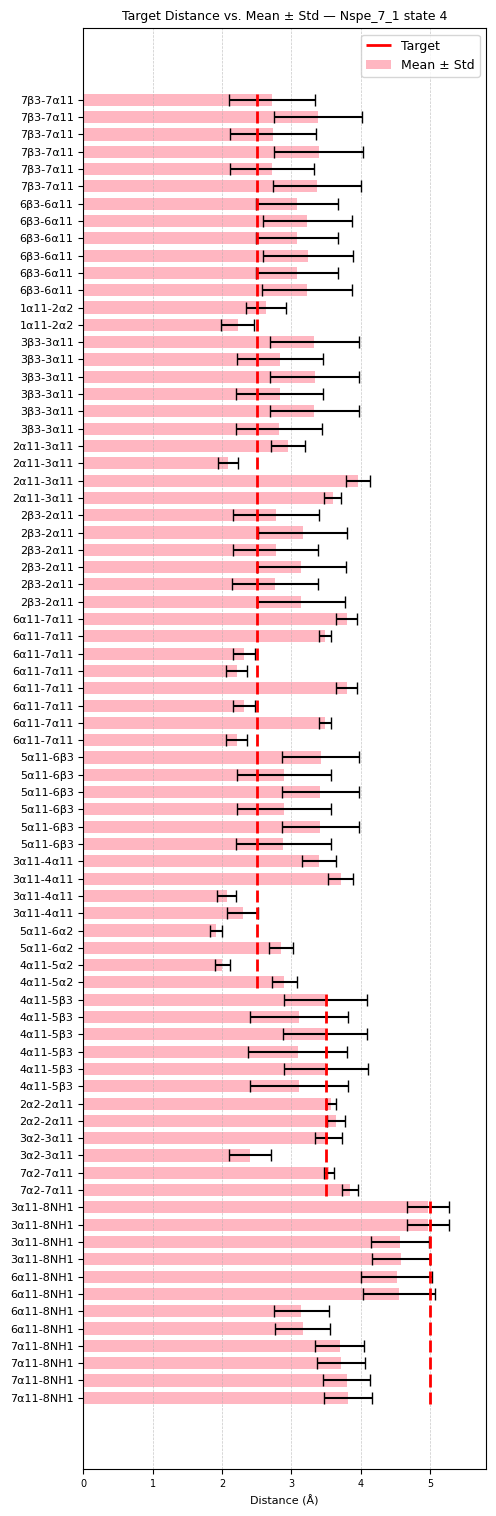

04-07-25 14:06:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1673] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1674] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1675] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

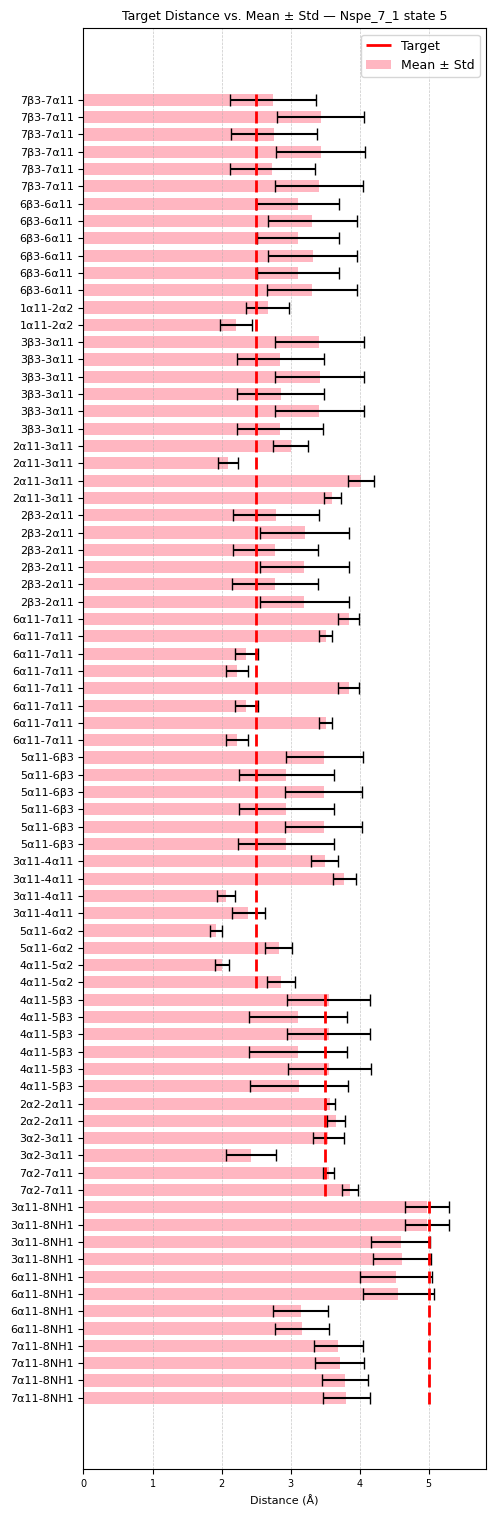

04-07-25 14:06:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1749] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1750] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1751] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

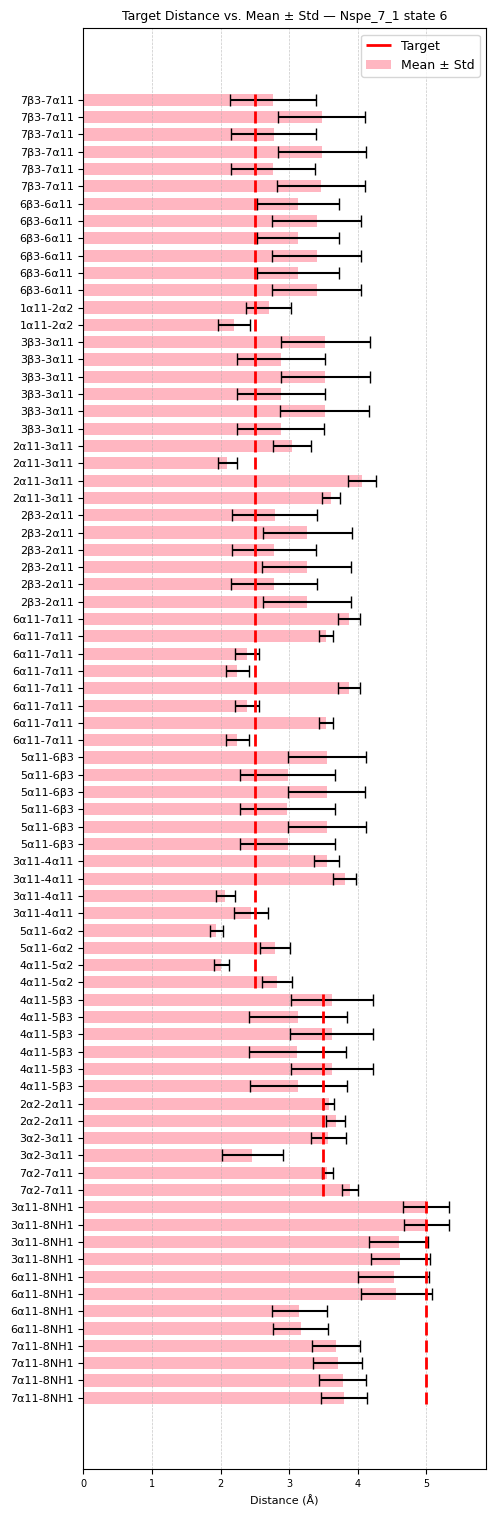

04-07-25 14:06:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1825] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1826] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1827] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

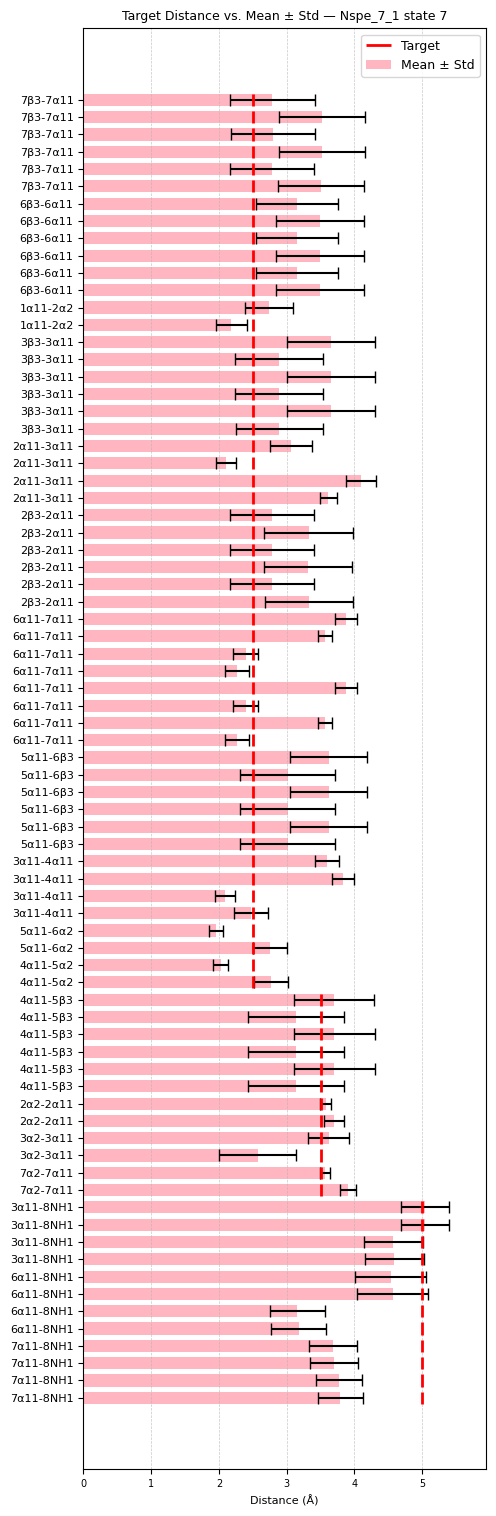

04-07-25 14:06:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1901] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1902] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1903] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

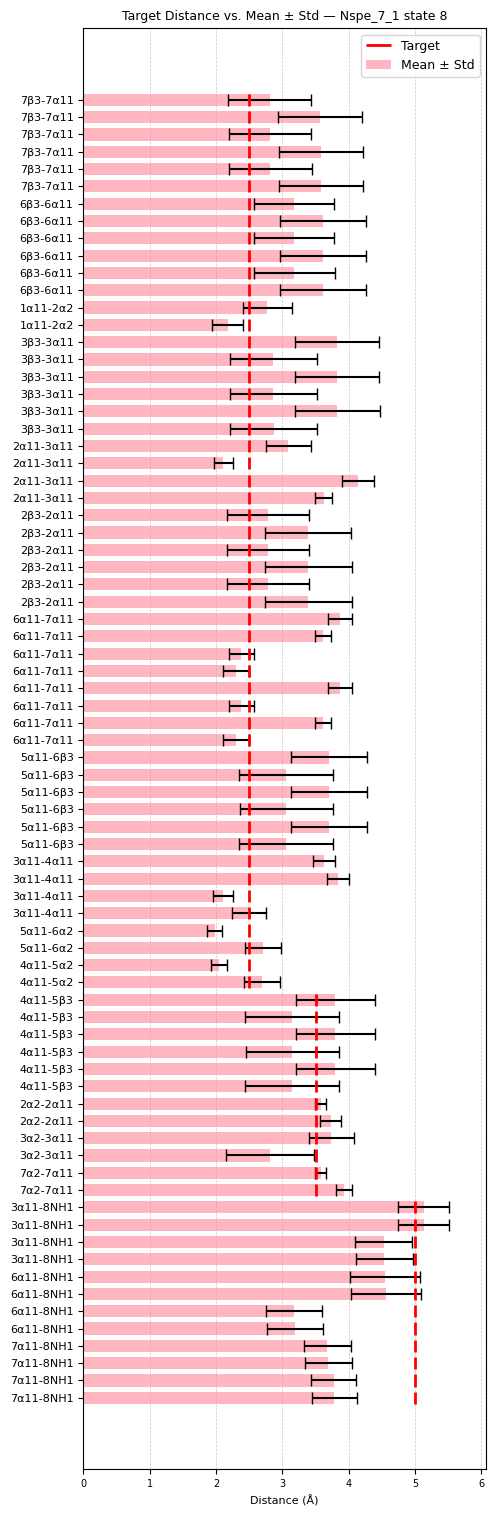

04-07-25 14:06:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1977] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1978] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:27 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[1979] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

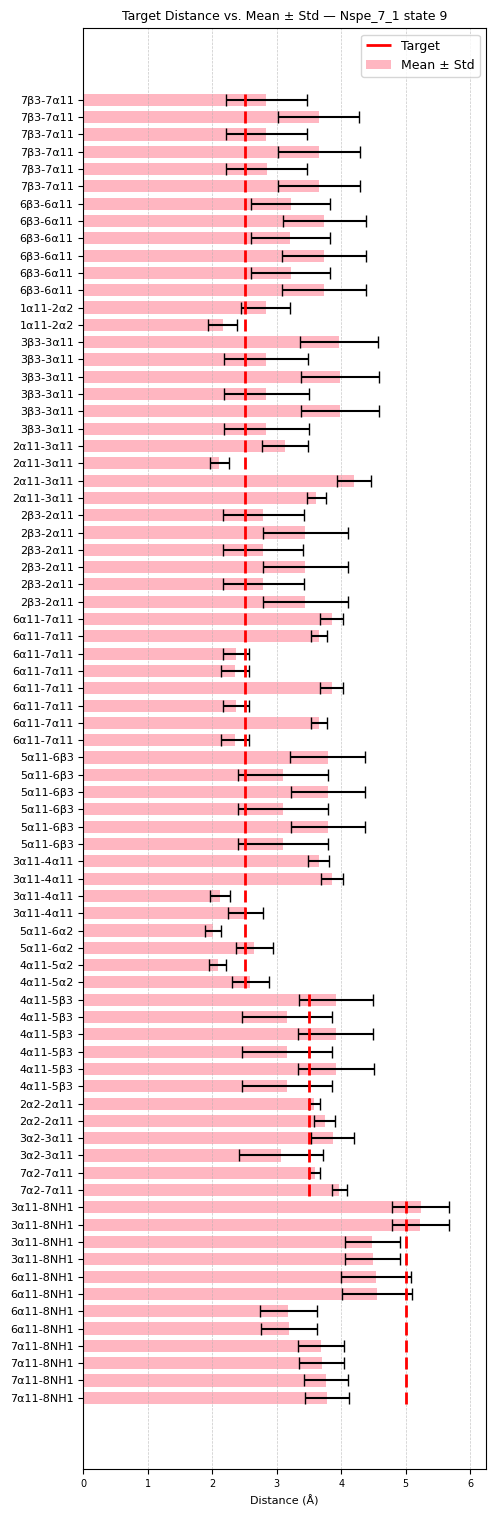

04-07-25 14:06:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2053] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2054] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2055] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

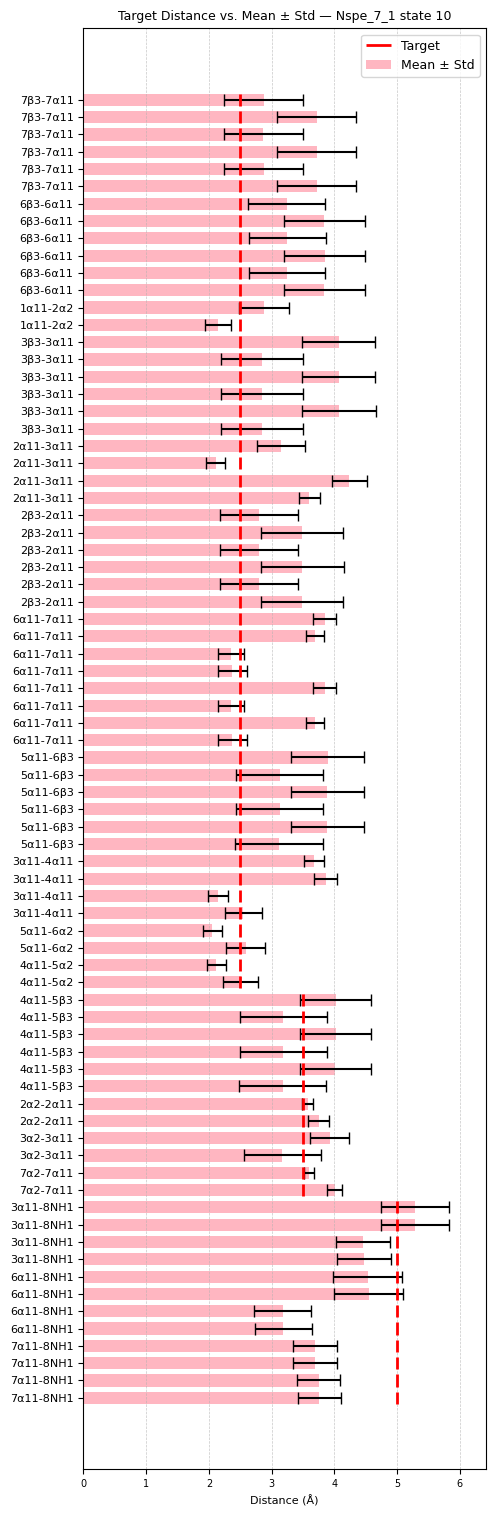

04-07-25 14:06:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2129] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2130] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:28 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2131] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

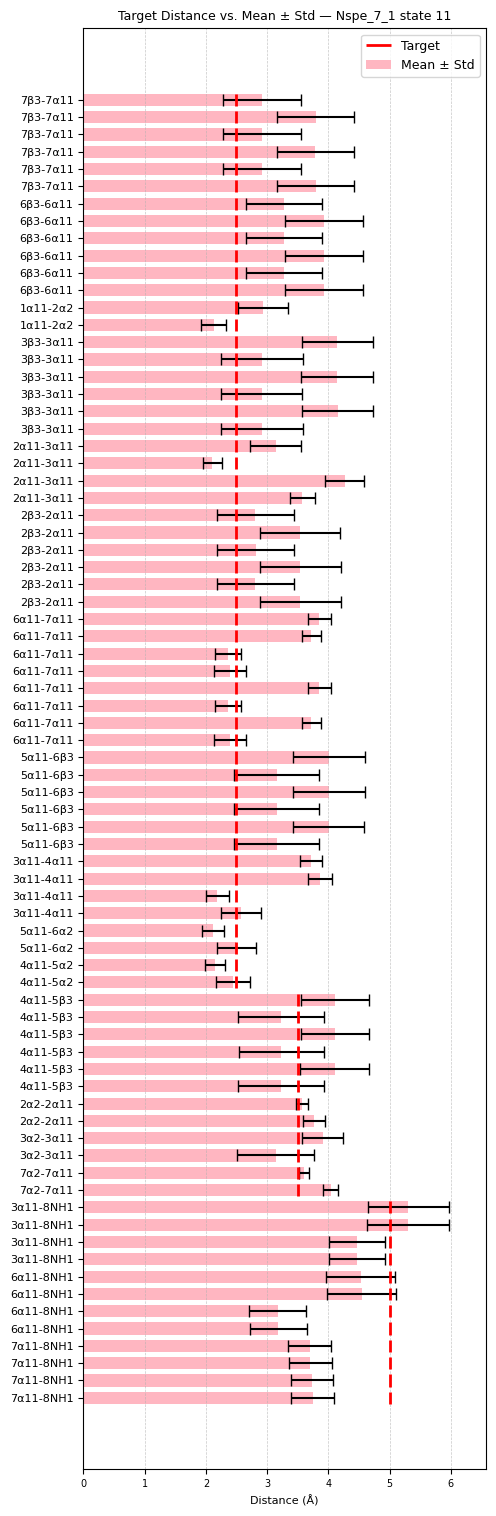

04-07-25 14:06:29 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2205] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:29 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2206] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:29 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2207] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

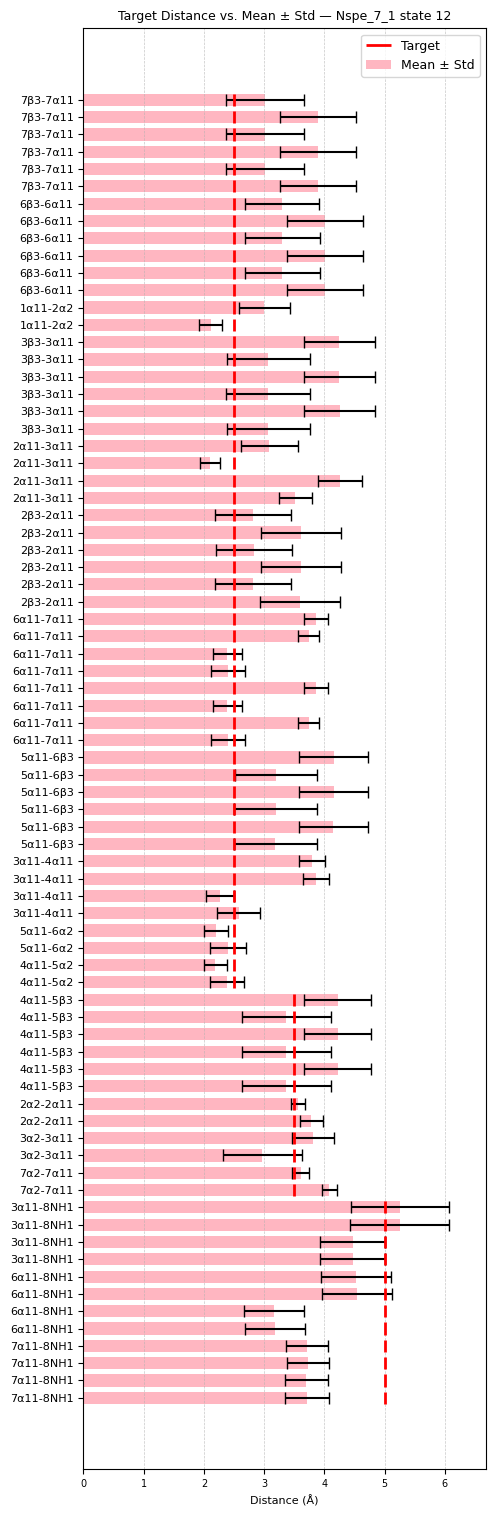

04-07-25 14:06:29 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2281] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:29 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2282] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:29 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2283] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

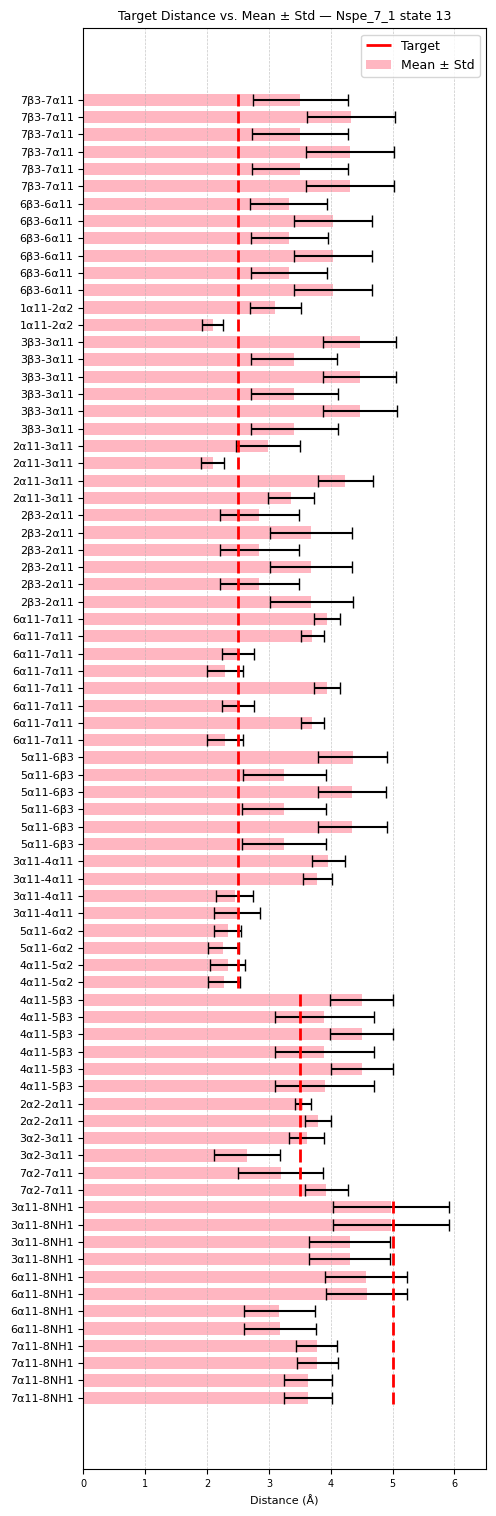

04-07-25 14:06:30 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2357] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:30 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2358] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:30 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2359] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

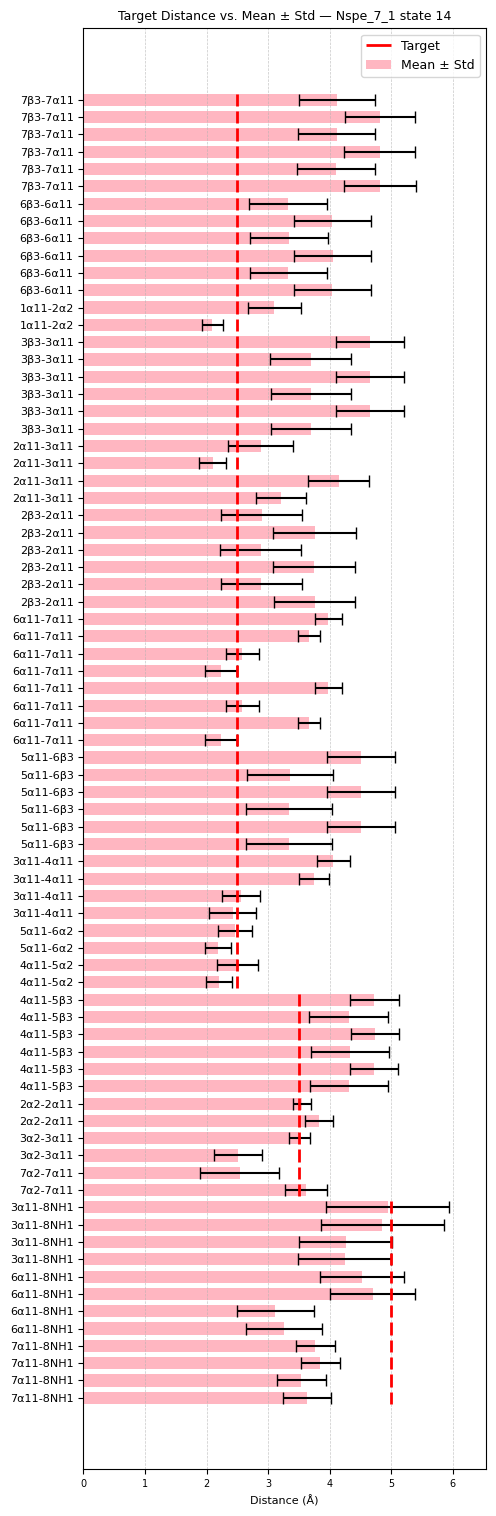

04-07-25 14:06:30 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2433] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
04-07-25 14:06:30 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2434] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
04-07-25 14:06:30 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[2435] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the ou

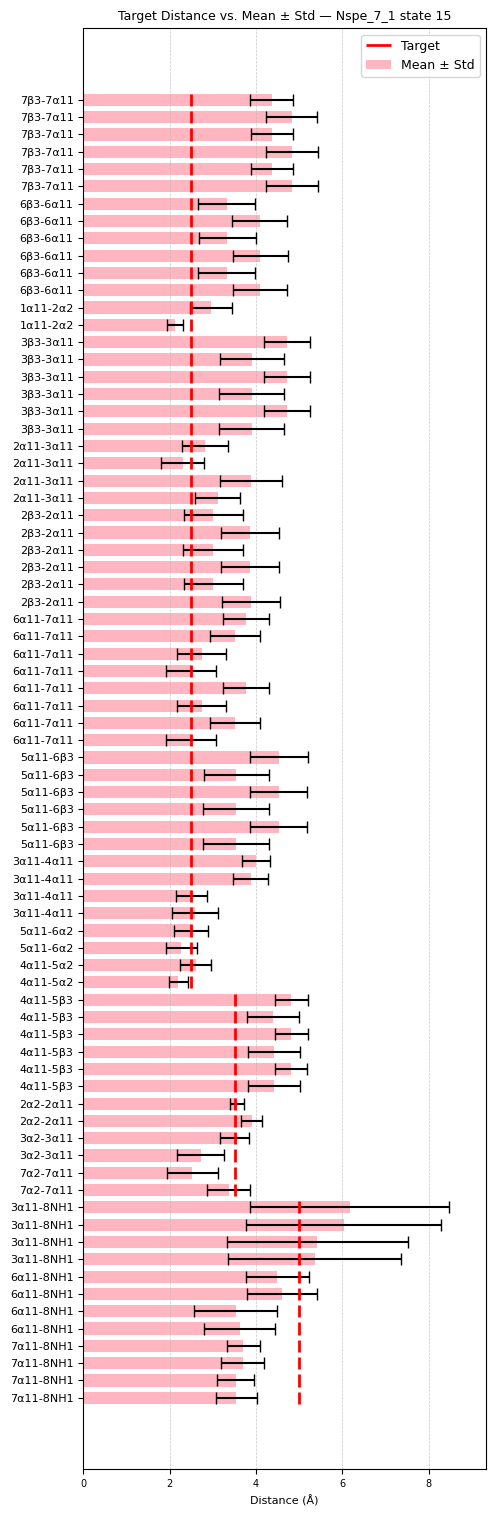

In [21]:
state_num = 16

human_interpretable_label = True


for state in range(state_num):
    means = []
    stds = []
    targets = []
    labels = []

    for i in range(len(dist_res)):
        atom1, atom2, target = dist_res[i]
        atom1_pyemma = atom1 - 1
        atom2_pyemma = atom2 - 1
        dist = dist_all[state][:, i]

        mean_val = np.mean(dist)
        std_val = np.std(dist)

        means.append(mean_val)
        stds.append(std_val)
        targets.append(target)

        grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
        feat = pyemma.coordinates.featurizer(grofile)
        feat.add_distances([atom1_pyemma, atom2_pyemma])
        label = feat.describe()[0]
        
        if human_interpretable_label:
            labels.append(translate_pyemma_label(label=label))
        else:
            labels.append(label)

    # Convert to arrays
    means = np.array(means)
    stds = np.array(stds)
    targets = np.array(targets)

    y = np.arange(len(labels))
    height = 0.7

    plt.figure(figsize=(5, max(6, len(labels) * 0.2)))

    # Horizontal bars: mean ± std
    plt.barh(y, means, height=height, xerr=stds, capsize=4, label='Mean ± Std', color='lightpink')

    # Draw target distances as vertical ticks
    target_label_plotted = False
    for yi, ti in zip(y, targets):
        if not target_label_plotted:
            plt.vlines(ti, yi - height/2, yi + height/2, colors='red', linestyles='-', linewidth=2, label='Target')
            target_label_plotted = True
        else:
            plt.vlines(ti, yi - height/2, yi + height/2, colors='red', linestyles='-', linewidth=2)

    plt.yticks(y, labels, fontsize=8)
    plt.xlabel("Distance (Å)")
    plt.title(f"Target Distance vs. Mean ± Std — Nspe_7_1 state {state}")
    plt.xlim(0, max(np.max(means + stds), np.max(targets)) * 1.1)
    plt.legend()
    plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()


### Distrances Over Time

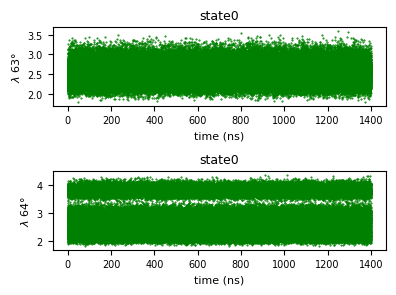

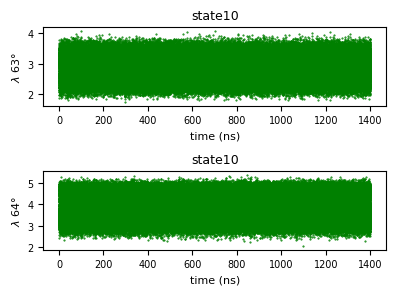

In [22]:
start = 0
nsnaps = dist_all.shape[1]
nreps = dist_all.shape[0]

residues_to_plot = [63, 64] # 1

#residues_to_plot = [0, 14, 70, 60] #5



num_residues = len(residues_to_plot)

ShowPlots = True

# Set default font sizes globally
plt.rc('font', size=8)         # controls default text sizes
plt.rc('axes', titlesize=9)    # fontsize of the axes title
plt.rc('axes', labelsize=8)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=7)   # fontsize of the tick labels
plt.rc('ytick', labelsize=7)   # fontsize of the tick labels
plt.rc('legend', fontsize=9)   # legend fontsize

# Plot omega angles vs time for selected residues for each replica
for i in [0, 10]:
    plt.figure(figsize=(4, 3))
    for panel, residue in enumerate(residues_to_plot, 1):
        plt.subplot(num_residues, 1, panel)
        t = np.arange(start, nsnaps) * 0.010  # Time axis in ns
        plt.plot(t, dist_all[i, start:nsnaps, residue], '.', ms=1, color='green')
        plt.xlabel('time (ns)')
        plt.ylabel(f'$\\lambda$ {residue}°')
    
        plt.title(f'state{i}')    
    plt.tight_layout()
    #plt.show()

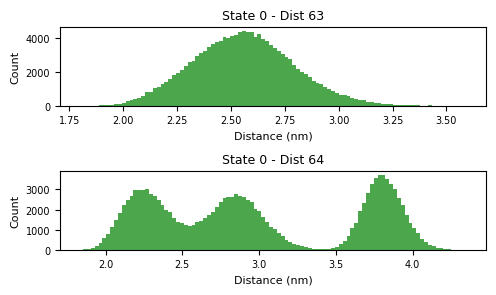

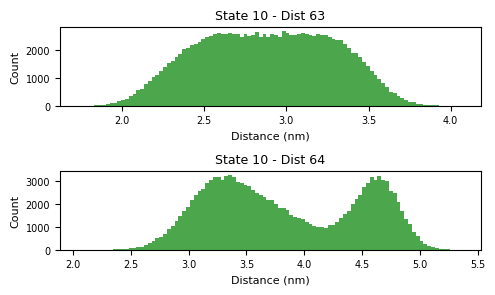

In [23]:
### Restrains Selected to show the effect, DON'T DELETE!!!!!!!!
#residues_to_plot = [63, 64] # 1 a11 - 2 a2
#residues_to_plot = [53, 54, 55, 56] # 2 a11 - 3 a11
#residues_to_plot = [29, 30, 31, 32] # 3 a11 - 4 a11
#residues_to_plot = [25, 26] # 4 a11 - 5 a2
#residues_to_plot = [27, 28] # 5 a11 - 6 a2
#residues_to_plot = [39, 40, 41, 42] # 6 a11 - 7 a11
#residues_to_plot = [9, 10, 11, 12] # 3 a11 - 8 nh1

num_residues = len(residues_to_plot)
start = 0
nsnaps = dist_all.shape[1]
nreps = dist_all.shape[0]

for i in [0, 10]:  # loop over selected replicas
    plt.figure(figsize=(5, 1.5 * num_residues))  # Adjust figure height dynamically
    for panel, residue in enumerate(residues_to_plot, 1):
        plt.subplot(num_residues, 1, panel)
        distances = dist_all[i, start:nsnaps, residue]
        plt.hist(distances, bins=100, color='green', alpha=0.7)
        plt.xlabel(f'Distance (nm)')
        plt.ylabel('Count')
        #plt.xlim(0.1, 0.7)
        plt.title(f'State {i} - Dist {residue}')
    plt.tight_layout()
    plt.show()


## Extract omega & phi restraints 

In [30]:
# hand input the omega indices:
# Define omega dihedral indices, gromcas start from 1, while np start from 0
gmx_dihedral_indices = np.array([
    [10, 11, 26, 44],
    [11, 26, 44, 47],
    [44, 47, 49, 67], 
    [47, 49, 67, 70],
    [67, 70, 72, 90],
    [70, 72, 90, 93],  
    [90, 93, 95, 113],
    [93, 95, 113, 116], 
    [113, 116, 118, 136],
    [116, 118, 136, 139],
    [136, 139, 141, 159],
    [139, 141, 159, 162]
])

omega_dihedral_indices = gmx_dihedral_indices - 1
print(omega_dihedral_indices)


HREX_list = [f"HREX_200ns_{i}" for i in range(1, run_num + 1)]
for state in range(state_num):
    omegas_list = []
    for HREX in HREX_list:
        HREX_path = f"{HREX_dir}/{HREX}"  

        xtcfile = f"{HREX_path}/state_{state}/HREMD.part0001.xtc"
        grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
        
        # Load the trajectory
        traj = md.load(xtcfile, top=grofile)
        
        # Compute omega dihedrals
        omegas = md.compute_dihedrals(traj, omega_dihedral_indices) * (180.0 / math.pi)
        omegas_list.append(omegas)
    # Save omegas
    concatenated_omegas = np.vstack(omegas_list)
    data_object = Data(concatenated_omegas)
    save_path = f"{omega_path}omegas_state{state}.pkl"
    data_object.save(save_path)
    print(f"Saved omegas for state {state} to {save_path}")

[[  9  10  25  43]
 [ 10  25  43  46]
 [ 43  46  48  66]
 [ 46  48  66  69]
 [ 66  69  71  89]
 [ 69  71  89  92]
 [ 89  92  94 112]
 [ 92  94 112 115]
 [112 115 117 135]
 [115 117 135 138]
 [135 138 140 158]
 [138 140 158 161]]
Saved omegas for state 0 to traj_data/omegas_state0.pkl
Saved omegas for state 1 to traj_data/omegas_state1.pkl
Saved omegas for state 2 to traj_data/omegas_state2.pkl
Saved omegas for state 3 to traj_data/omegas_state3.pkl
Saved omegas for state 4 to traj_data/omegas_state4.pkl
Saved omegas for state 5 to traj_data/omegas_state5.pkl
Saved omegas for state 6 to traj_data/omegas_state6.pkl
Saved omegas for state 7 to traj_data/omegas_state7.pkl
Saved omegas for state 8 to traj_data/omegas_state8.pkl
Saved omegas for state 9 to traj_data/omegas_state9.pkl
Saved omegas for state 10 to traj_data/omegas_state10.pkl
Saved omegas for state 11 to traj_data/omegas_state11.pkl
Saved omegas for state 12 to traj_data/omegas_state12.pkl
Saved omegas for state 13 to traj_dat

In [31]:
nstates = 16

omega_all = []
for i in range(nstates):
    omega_path = f"traj_data/omegas_state{i}.pkl"
    omegas = Data.load(omega_path)
    omegas = omegas.array_list
    print(f'state {i}:, {np.array(omegas).shape}')
    omega_all.append(omegas)

omega_all = np.array(omega_all)
omega_all.shape

state 0:, (140007, 12)
state 1:, (140007, 12)
state 2:, (140007, 12)
state 3:, (140007, 12)
state 4:, (140007, 12)
state 5:, (140007, 12)
state 6:, (140007, 12)
state 7:, (140007, 12)
state 8:, (140007, 12)
state 9:, (140007, 12)
state 10:, (140007, 12)
state 11:, (140007, 12)
state 12:, (140007, 12)
state 13:, (140007, 12)
state 14:, (140007, 12)
state 15:, (140007, 12)


(16, 140007, 12)

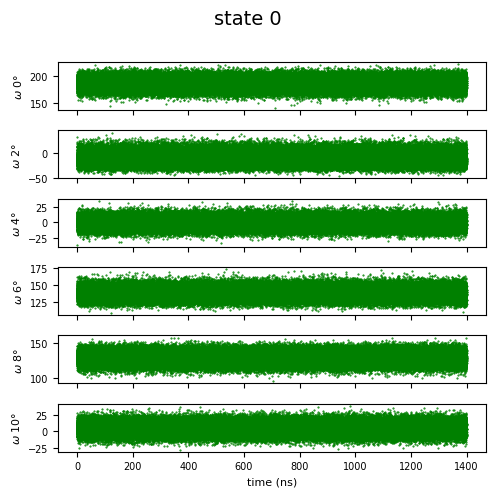

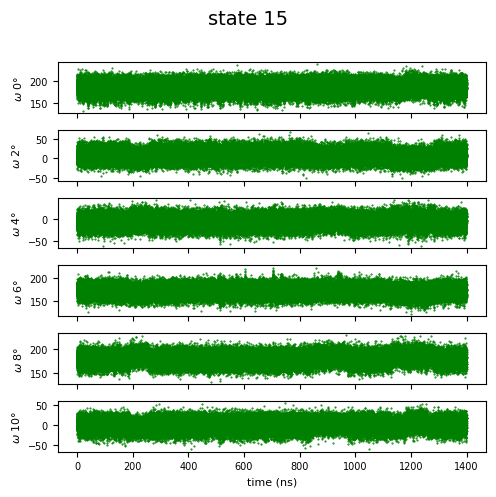

In [32]:
residues_to_plot = np.arange(0, 12, 2).tolist()

# Apply wrapping only to the selected phi columns
omega_all[:, :, residues_to_plot] = (omega_all[:, :, residues_to_plot] + 90.0) % 360.0 - 90.0

start = 0
nsnaps = omega_all.shape[1]
nreps = omega_all.shape[0]

num_residues = len(residues_to_plot)

ShowPlots = True

# Set default font sizes globally
plt.rc('font', size=8)         # controls default text sizes
plt.rc('axes', titlesize=9)    # fontsize of the axes title
plt.rc('axes', labelsize=8)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=7)   # fontsize of the tick labels
plt.rc('ytick', labelsize=7)   # fontsize of the tick labels
plt.rc('legend', fontsize=9)   # legend fontsize

# Plot omega angles vs time for selected residues for each replica
for i in [0, 15]:
    fig, axes = plt.subplots(nrows=num_residues, ncols=1, figsize=(5, 5), sharex=True)
    t = np.arange(start, nsnaps) * 0.010  # Time axis in ns

    for panel, (residue, ax) in enumerate(zip(residues_to_plot, axes)):
        ax.plot(t, omega_all[i, start:nsnaps, residue], '.', ms=1, color='green')
        ax.set_ylabel(f'$\\omega$ {residue}°')

        # Only label x-axis on the bottom subplot
        if panel == num_residues - 1:
            ax.set_xlabel('time (ns)')

    fig.suptitle(f'state {i}', fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle
    plt.show()

### Omega vs Phi

In [33]:
omega_all.shape

(16, 140007, 12)

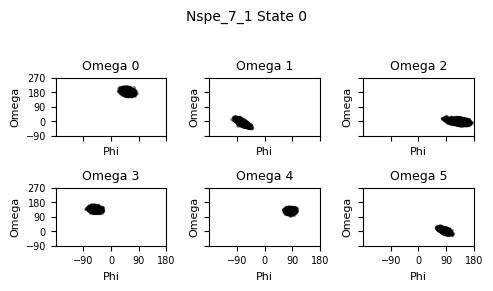

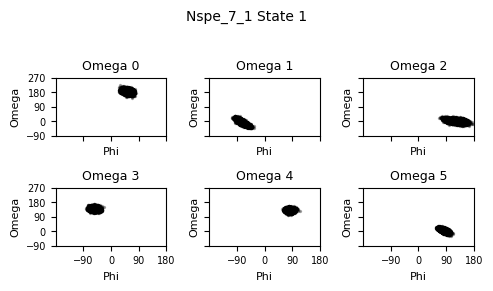

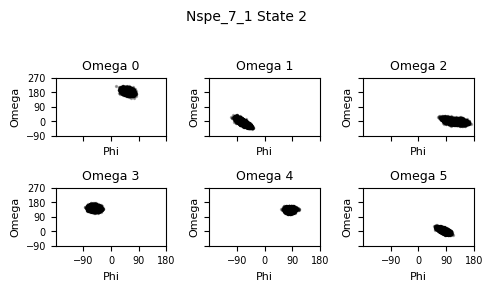

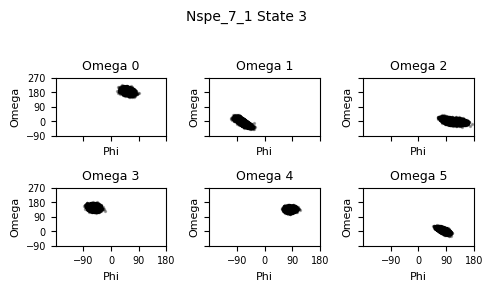

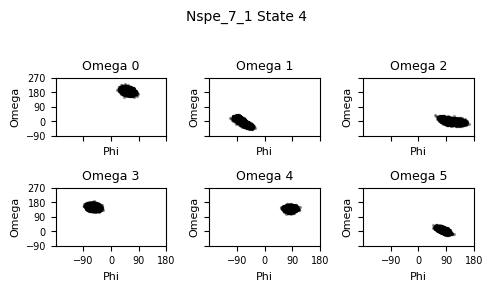

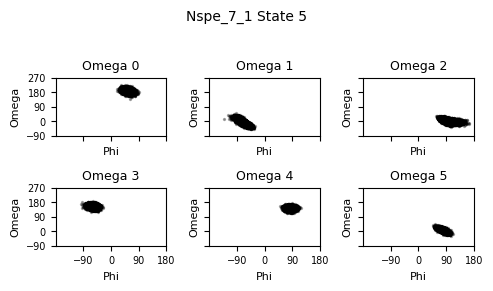

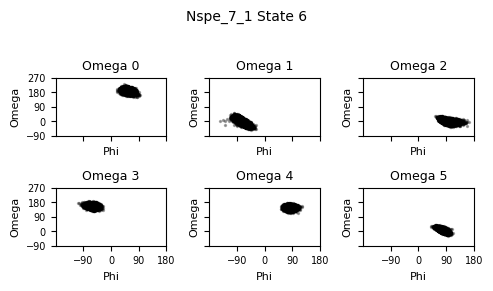

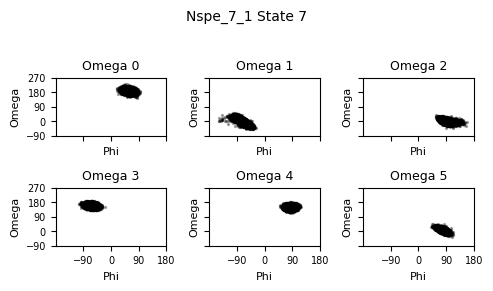

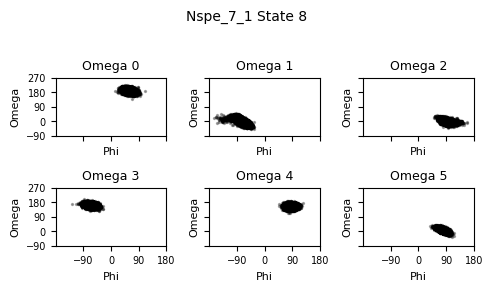

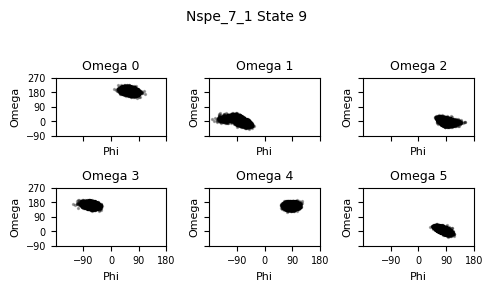

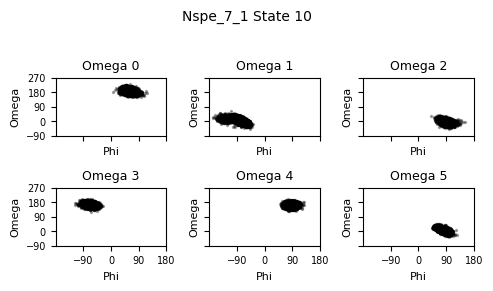

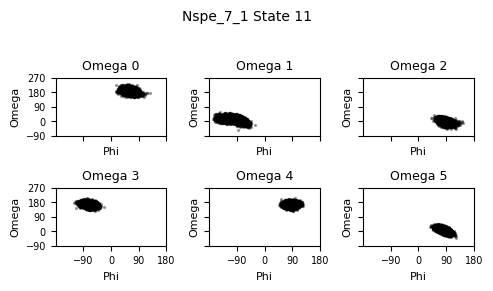

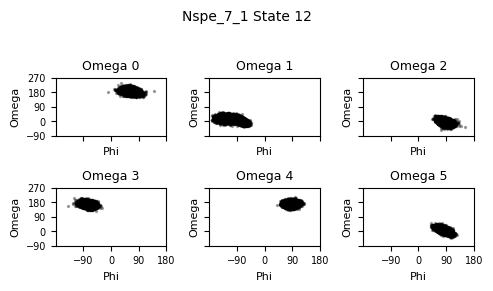

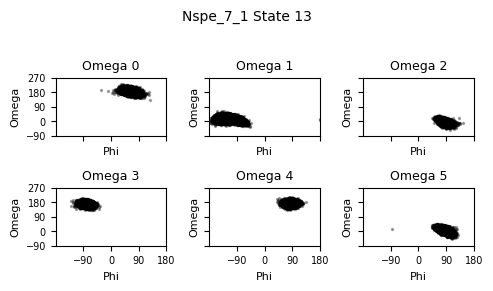

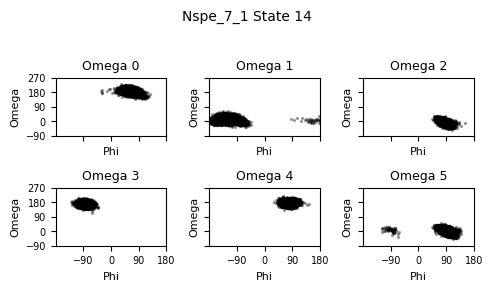

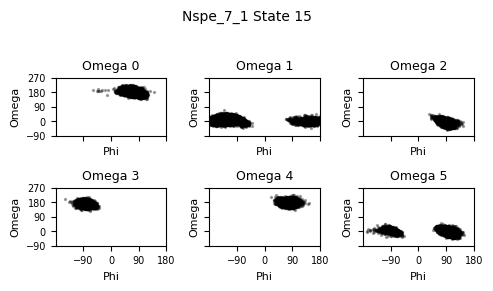

In [34]:
residues_to_plot = np.arange(0, 12, 2).tolist()  # residues: 0, 2, 4, 6, 8, 10

# Set default font sizes globally
plt.rc('font', size=9)
plt.rc('axes', titlesize=9)
plt.rc('axes', labelsize=8)
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)
plt.rc('legend', fontsize=9)

# Plot in 2 x 3 grid for each selected replica
for i in range(0, 16):  # state indices
#for i in [0]:  # state indices
    fig, axes = plt.subplots(2, 3, figsize=(5, 3), sharex=True, sharey=True)
    fig.suptitle(f'Nspe_7_1 State {i}', fontsize=10)
    
    for idx, residue in enumerate(residues_to_plot):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]

        phi = omega_all[i, :, residue + 1][::10]
        omega = omega_all[i, :, residue][::10]

        #sns.kdeplot(x=phi, y=omega, fill=True, cmap="viridis", thresh=0.05, ax=ax)
        # Plot actual data points
        ax.scatter(phi, omega, s=2, color='black', alpha=0.3)  # small, semi-transparent dots


        # Add more ticks every 90 degrees
        ticks = np.arange(-90, 271, 90)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xlim(-180, 180)
        ax.set_ylim(-90, 270)
        ax.set_xlabel('Phi')
        ax.set_ylabel('Omega')
        ax.set_title(f'Omega {residue // 2}')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space for the suptitle
    plt.show()


In [ ]:
data_path = 'traj_data/omegas_state0.pkl'

# Load the data
loaded_data = Data.load(data_path)
# Access the list of arrays
array_list = loaded_data.array_list

# Print a slice of the data
print(array_list[200:205])
# Print the shape
print(np.array(array_list).shape)

[[ 177.67072     61.70175    -17.776463   -70.75977      4.5663233
   110.520744   152.64021    -55.35803    136.32346     87.29567
     5.0415187   88.386024 ]
 [ 170.31673     50.331753   -11.83565    -77.02946     -3.5215836
   135.8148     140.44284    -54.98942    127.757614    90.93287
     2.1559937   81.38686  ]
 [ 178.75534     57.24438    -14.649246   -68.227135   -17.579546
   162.57002    137.03818    -50.848194   123.50978     77.47064
    11.675043    75.72607  ]
 [-176.75822     37.61869    -15.263175   -72.62558      4.0833416
   138.37796    140.96469    -44.88588    112.01566     88.58931
    -4.278215    84.94293  ]
 [-176.29807     53.81346    -17.318718   -67.55857      8.220155
   124.79014    140.10144    -44.17181    125.40501     80.36221
    11.350698    75.88452  ]]
(140007, 12)


In [ ]:
for i in range(nstates):
    omega_path = f"traj_data/omegas_state{i}.pkl"
    omegas = Data.load(omega_path)
    omegas = omegas.array_list
    print(f'state {i}:, {np.array(omegas).shape}')

state 0:, (140007, 12)
state 1:, (140007, 12)
state 2:, (140007, 12)
state 3:, (140007, 12)
state 4:, (140007, 12)
state 5:, (140007, 12)
state 6:, (140007, 12)
state 7:, (140007, 12)
state 8:, (140007, 12)
state 9:, (140007, 12)
state 10:, (140007, 12)
state 11:, (140007, 12)
state 12:, (140007, 12)
state 13:, (140007, 12)
state 14:, (140007, 12)
state 15:, (140007, 12)


## Extract the exchanged stated from log file

In [ ]:
current_state = np.arange(0, state_num, 1).tolist()
current_state


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [ ]:
pattern = 'Repl ex'
output_file = 'replica_indices.dat'

states = []
states.append( current_state.copy() ) # Make a copy of initial_state

# DEbug:  Let's see if xtc is written BEFORE swap 
states.append( current_state.copy() ) # Make a copy of initial_state

VERBOSE = False

for HREX in HREX_list:
    HREX_path = f"{HREX_dir}/{HREX}"
    try:
        logfile = os.path.join(HREX_path , 'state_0/HREMD.part0001.log')
        with open(logfile, 'r') as file:
            lines = file.readlines()

            for line in lines:
                if pattern in line:
                    parts = line.strip().split()
                    if VERBOSE:
                        print(f'parts: {parts}')
                    for i in range(2, len(parts)):
                        if 'x' in parts[i]:
                            index1 = int(parts[i-1])
                            index2 = int(parts[i+1])
                            if VERBOSE:
                                print(current_state)
                                print('index1, index2', index1, index2)
                            # Swap the positions in the current state
                            tmp1, tmp2 = current_state[index1], current_state[index2]
                            if VERBOSE:
                                print('tmp1, tmp2', tmp1, tmp2)
                            current_state[index2] = tmp1
                            current_state[index1] = tmp2
                            if VERBOSE:
                                print(current_state)
                    states.append(current_state.copy())  # Append a copy of the last state
        
        # Append twice for the last frame
        states.append(current_state.copy())
        states.append(current_state.copy())

    except FileNotFoundError:
        print(f"The file {logfile} does not exist.")
    except Exception as e:
        print(f"An error occurred: {e}")

# Remove the final two lines from states
if len(states) > 2:
    states = states[:-2]


# Write states to output_file
with open(output_file, 'w') as outfile:
    for state in states:
        outfile.write(' '.join(map(str, state)) + '\n')

print(f"Output saved to {output_file}")


Output saved to replica_indices.dat


In [ ]:
states = np.array(states)
states.shape

(700007, 16)

In [ ]:
states = np.array(states)

state_all = []

block_size = 100001
stride = 5
for i, label in enumerate(HREX_list):
    print(i, label)

    start = block_size * i
    end = block_size * (i + 1)
    state = states[start:end:stride]
    state_all.append(state)
    print(f"state_{label}.shape = {state.shape}")

# Stack and save
state_new = np.vstack(state_all)
print(f"state_new.shape = {state_new.shape}")
np.savetxt('state_new.dat', state_new.astype(int), fmt='%d')
print("Saved data at state_new.dat")

0 HREX_200ns_1
state_HREX_200ns_1.shape = (20001, 16)
1 HREX_200ns_2
state_HREX_200ns_2.shape = (20001, 16)
2 HREX_200ns_3
state_HREX_200ns_3.shape = (20001, 16)
3 HREX_200ns_4
state_HREX_200ns_4.shape = (20001, 16)
4 HREX_200ns_5
state_HREX_200ns_5.shape = (20001, 16)
5 HREX_200ns_6
state_HREX_200ns_6.shape = (20001, 16)
6 HREX_200ns_7
state_HREX_200ns_7.shape = (20001, 16)
state_new.shape = (140007, 16)
Saved data at state_new.dat


## Extract each replica 

In [ ]:
nres = 12
state_num = 16
all_omegas = [] # Load in the omega values for all replicas

for state in range(state_num):  # Adjust the range to include all replicas
    omega_path = f"traj_data/omegas_state{state}.pkl"
    omegas = Data.load(omega_path)
    omegas = omegas.array_list
    all_omegas.append(np.array(omegas))
all_omegas = np.array(all_omegas)  # (nreps, nsnaps, nresidues)
print('all_omegas.shape', all_omegas.shape)
#print(all_omegas[:5])

# Arrange each snapshot by replica (not temp)
replica_indices = np.loadtxt('state_new.dat')
print("replica_indices.shape", replica_indices.shape)
#print(replica_indices)

start = 0
nsnaps = replica_indices.shape[0]
nreps = state_num

all_omegas_by_replica = np.zeros(all_omegas.shape)
all_omegas_by_replica_and_state = np.zeros((nreps, nsnaps, nres + 1)) # Make a instance recorded teh state and replica 
replica_indices_sorted = np.zeros_like(replica_indices)

for i in range(nsnaps):
    Ind = np.argsort(replica_indices[i, :])
    all_omegas_by_replica[:, i, :] = all_omegas[Ind, i, :]
    replica_indices_sorted[i, :] = Ind

# Save the data for each state once
for rep in range(nreps):
    save_path = f"traj_data/omegas_rep{rep}.pkl"
    rep_object = Data(all_omegas_by_replica[rep, :, :])
    rep_object.save(save_path)
    print(f"Saved omegas for replica {rep} to {save_path}")
    #print(np.load(f'omega_data/omegas_rep{rep}.npy')[:5])

# Create a replica + state_indices 
for i in range(nsnaps):
    Ind = np.argsort(replica_indices[i, :]) # find the index of replica
    all_omegas_by_replica_and_state[:, i, :-1] = all_omegas[Ind, i, :]
    all_omegas_by_replica_and_state[:, i, -1] = Ind  # State is found by indexing
    #print(all_omegas_by_replica_and_state)

print('replica_indices_sorted.shape', replica_indices_sorted.shape)
print('replica_indices_sorted[:10, 0]', replica_indices_sorted[:10, 0])

all_omegas.shape (16, 140007, 12)
replica_indices.shape (140007, 16)
Saved omegas for replica 0 to traj_data/omegas_rep0.pkl
Saved omegas for replica 1 to traj_data/omegas_rep1.pkl
Saved omegas for replica 2 to traj_data/omegas_rep2.pkl
Saved omegas for replica 3 to traj_data/omegas_rep3.pkl
Saved omegas for replica 4 to traj_data/omegas_rep4.pkl
Saved omegas for replica 5 to traj_data/omegas_rep5.pkl
Saved omegas for replica 6 to traj_data/omegas_rep6.pkl
Saved omegas for replica 7 to traj_data/omegas_rep7.pkl
Saved omegas for replica 8 to traj_data/omegas_rep8.pkl
Saved omegas for replica 9 to traj_data/omegas_rep9.pkl
Saved omegas for replica 10 to traj_data/omegas_rep10.pkl
Saved omegas for replica 11 to traj_data/omegas_rep11.pkl
Saved omegas for replica 12 to traj_data/omegas_rep12.pkl
Saved omegas for replica 13 to traj_data/omegas_rep13.pkl
Saved omegas for replica 14 to traj_data/omegas_rep14.pkl
Saved omegas for replica 15 to traj_data/omegas_rep15.pkl
replica_indices_sorted.

## Replica Move through states

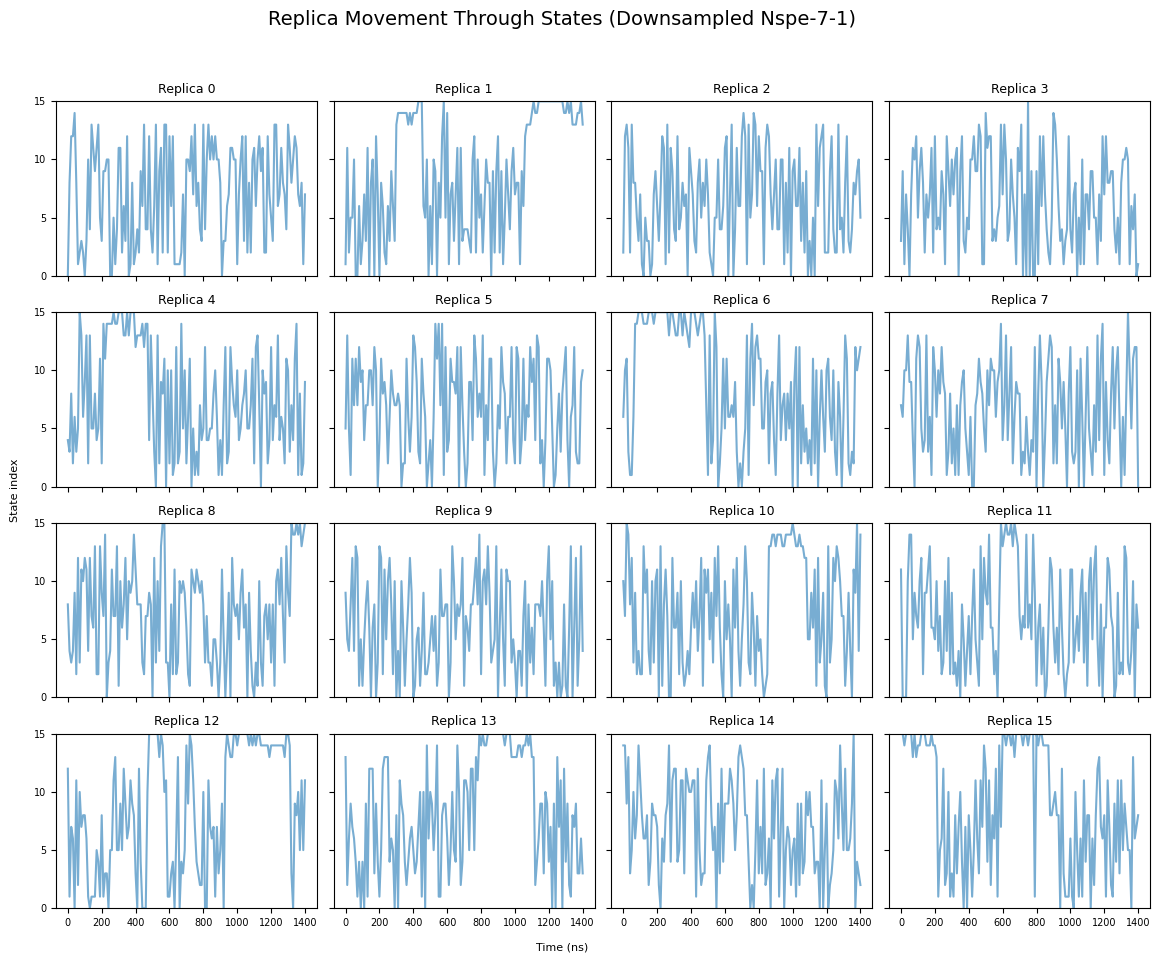

In [ ]:
step = 1000
dt_in_ns = 0.01
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10), sharex=True, sharey=True)

for replica_id in range(replica_indices_sorted.shape[1]):
    ax = axes[replica_id // ncols, replica_id % ncols]

    x = np.arange(0, replica_indices_sorted.shape[0], step) * dt_in_ns
    y = replica_indices_sorted[:, replica_id][::step]

    ax.plot(x, y, alpha=0.6)
    ax.set_title(f"Replica {replica_id}")
    ax.set_ylim(0, 15)
    ax.set_yticks([0, 5, 10, 15])

fig.suptitle("Replica Movement Through States (Downsampled Nspe-7-1)", fontsize=14)
fig.text(0.5, 0.04, 'Time (ns)', ha='center')
fig.text(0.04, 0.5, 'State index', va='center', rotation='vertical')
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()


In [ ]:
all_omegas_by_replica.shape

(16, 140007, 12)

In [ ]:
## Plot the Omega

residues_to_plot = np.arange(0, 12, 2).tolist()

# Apply wrapping only to the selected phi columns
all_omegas_by_replica[:, :, residues_to_plot] = (all_omegas_by_replica[:, :, residues_to_plot] + 90.0) % 360.0 - 90.0


start = 0
nsnaps = all_omegas_by_replica.shape[1]
num_residues = len(residues_to_plot)

ShowPlots = True

# Set default font sizes globally
plt.rc('font', size=8)         # controls default text sizes
plt.rc('axes', titlesize=9)    # fontsize of the axes title
plt.rc('axes', labelsize=8)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=7)   # fontsize of the tick labels
plt.rc('ytick', labelsize=7)   # fontsize of the tick labels
plt.rc('legend', fontsize=9)   # legend fontsize


# Plot omega angles vs time for selected residues for each replica
for i in range(1):
    plt.figure(figsize=(5, 6))
    for panel, residue in enumerate(residues_to_plot, 1):
        plt.subplot(num_residues, 1, panel)
        t = np.arange(start, nsnaps) * 0.010  # Time axis in ns
        plt.plot(t, all_omegas_by_replica[i, start:nsnaps, residue], '.', ms=1, color='tomato')
        plt.xlabel('time (ns)')
        plt.ylabel(f'$\\omega$ {residue}°')
        plt.title(f'Omega angles vs Time for replica {i} in Nspe_7_1')
        
    plt.tight_layout()
    if ShowPlots:
        plt.show()
    else:
        outfilename = f'traj_data/Omega_angles_vs_Time_Replica_{i}_in_Nspe_7_1.png'
        plt.savefig(outfilename, format='png', transparent=True, dpi=600)
        print(f"Saved at: {outfilename}")
        plt.clf()  # Clear the figure for the next set of plots

# Plot phi angles vs time for selected residues for each replica
for i in range(16):
    fig, axes = plt.subplots(nrows=num_residues, ncols=1, figsize=(3, num_residues * 0.7), sharex=True)
    t = np.arange(start, nsnaps) * 0.010  # Time axis in ns

    for panel, (residue, ax) in enumerate(zip(residues_to_plot, axes)):
        ax.plot(t, all_omegas_by_replica[i, start:nsnaps, residue - 1], '.', ms=1, color='darkblue')
        ax.set_ylim(-180, 180)
        ax.set_yticks([-90, 90])
        ax.set_ylabel(f'$\\omega$ {residue}°')

        # Only set xlabel on the bottom subplot
        if panel == num_residues - 1:
            ax.set_xlabel('time (ns)')

    # Overall figure title
    fig.suptitle(f'Phi angles vs Time for replica {i} in Nspe_7_1')

    # Adjust layout to fit suptitle
    fig.tight_layout(rect=[0, 0, 0.2, 0.96])

    if ShowPlots:
        plt.show()
    else:
        outfilename = f'traj_data/Phi_angles_vs_Time_Replica_{i}_in_Nspe_7_1.png'
        fig.savefig(outfilename, format='png', transparent=True, dpi=600)
        print(f"Saved at: {outfilename}")
        plt.close(fig)  # Close the figure cleanly
        plt.clf()  # Clear the figure for the next set of plots

NameError: name 'np' is not defined

## Plot Omega Desity Plot

/var/folders/d8/y2dvs1ln1gjcwccrkvtffr240000gn/T/ipykernel_59860/4047350443.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('winter', num_replicas)


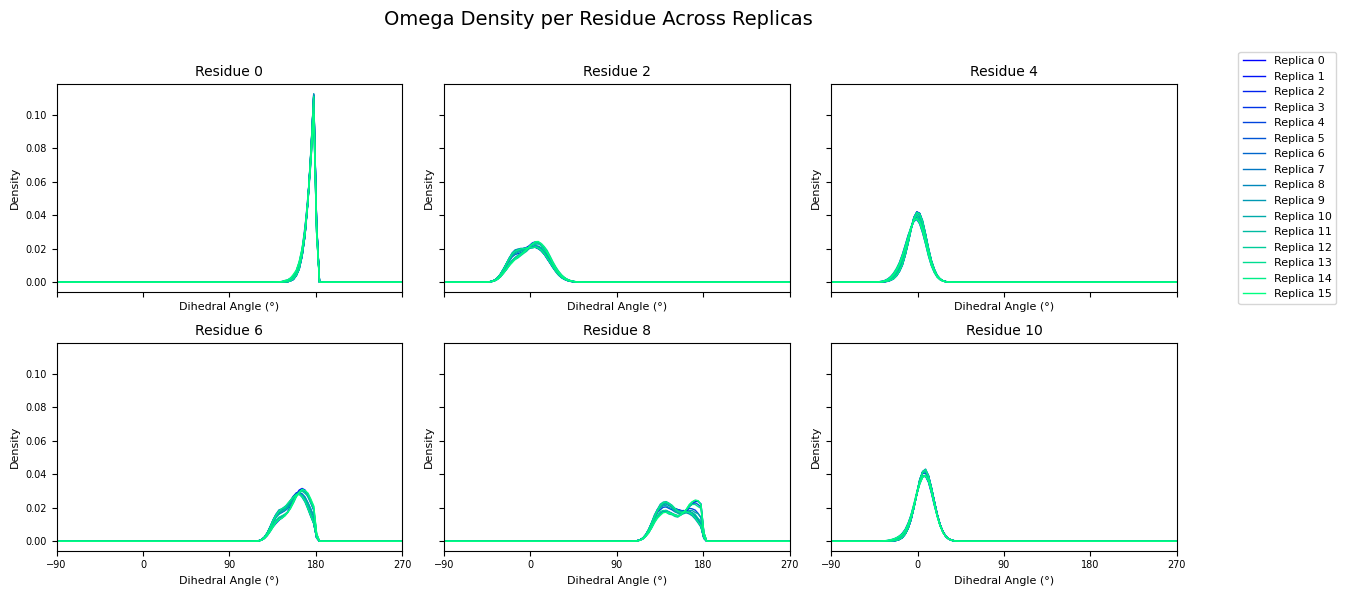

In [ ]:
residues_to_plot = np.arange(0, 12, 2).tolist()  # [0, 2, 4, 6, 8, 10]
num_residues = len(residues_to_plot)
num_replicas = all_omegas_by_replica.shape[0]

ShowPlots = True

# Plot settings
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.flatten()

cmap = cm.get_cmap('winter', num_replicas)
colors = [cmap(i) for i in range(num_replicas)]

bins = np.linspace(-90, 270, 120)

for idx, residue in enumerate(residues_to_plot):
    ax = axes[idx]
    for i in range(num_replicas):
        omega_values = all_omegas_by_replica[i, :, residue].flatten()
        hist, bin_edges = np.histogram(omega_values, bins=bins, density=True)
        
        # Close the histogram for circular plotting
        hist = np.append(hist, hist[0])
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_centers = np.append(bin_centers, bin_centers[0] + 360)

        ax.plot(bin_centers, hist, color=colors[i], label=f'Replica {i}', lw=1)

    ax.set_title(f'Residue {residue}', fontsize=10)
    ax.set_xlabel('Dihedral Angle (°)')
    ax.set_ylabel('Density')
    ax.set_xlim([-90, 270])
    ax.set_xticks([-90, 0, 90, 180, 270])

fig.suptitle('Omega Density per Residue Across Replicas', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])

# Add one legend outside the plot
fig.legend([f'Replica {i}' for i in range(num_replicas)], loc='upper right', bbox_to_anchor=(1.12, 0.92), fontsize=8)

# Save or show
if ShowPlots:
    plt.show()
else:
    outfilename = 'traj_data/Omega_Density_per_Residue_Over_Replicas.pdf'
    plt.savefig(outfilename, format='pdf', dpi=600, bbox_inches='tight', transparent=True)
    print(f"Saved at: {outfilename}")
    plt.clf()
